# Загрузка данных

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Данные взяты с сайта kaggle
[банковские транзакции](https://www.kaggle.com/datasets/shivamb/bank-customer-segmentation)

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Кейс/bank_clients_transactions.csv')

In [4]:
df

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


In [5]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='object')

# Приведение столбцов к стилю camel_case

In [6]:
camel_case = {
    'TransactionID': 'transaction_id',
    'CustomerID': 'customer_id',
    'CustomerDOB': 'customer_dob',
    'CustGender': 'cust_gender',
    'CustLocation': 'cust_location',
    'CustAccountBalance': 'cust_account_balance',
    'TransactionDate': 'transaction_date',
    'TransactionTime': 'transaction_time',
    'TransactionAmount (INR)': 'transaction_amount_inr'
}

# Переименование столбцов
df = df.rename(columns=camel_case)

# Приведение типов данных

In [7]:
#привести дату к типу datetime

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1048567 non-null  object 
 1   customer_id             1048567 non-null  object 
 2   customer_dob            1045170 non-null  object 
 3   cust_gender             1047467 non-null  object 
 4   cust_location           1048416 non-null  object 
 5   cust_account_balance    1046198 non-null  float64
 6   transaction_date        1048567 non-null  object 
 7   transaction_time        1048567 non-null  int64  
 8   transaction_amount_inr  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [9]:
import pandas as pd

# Преобразование с явным указанием формата
# Формат: день/месяц/год (двухзначный)
df['customer_dob'] = pd.to_datetime(
    df['customer_dob'],
    format='%d/%m/%y',  # день/месяц/год
    errors='coerce'
)

df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    format='%d/%m/%y',
    errors='coerce'
)

print("Типы данных после преобразования:")
print(df[['customer_dob', 'transaction_date']].dtypes)

Типы данных после преобразования:
customer_dob        datetime64[ns]
transaction_date    datetime64[ns]
dtype: object


# Поиск дублей и пропусков в данных

In [10]:
print("АНАЛИЗ ДУБЛИКАТОВ")

# Полные дубликаты строк
print("\nПОЛНЫЕ ДУБЛИКАТЫ СТРОК:")

full_duplicates = df.duplicated(keep=False)
full_duplicates_count = full_duplicates.sum()

print(f"Полных дубликатов строк: {full_duplicates_count:}")
print(f"Уникальных строк: {len(df) - full_duplicates_count:}")

# Частичные дубликаты по ключевым полям
print("\nЧАСТИЧНЫЕ ДУБЛИКАТЫ:")

# Определяем ключевые поля для поиска дублей
key_columns = ['customer_id', 'transaction_id']

for i, col in enumerate(key_columns, 1):
    duplicates_in_col = df.duplicated(subset=[col], keep=False)
    count = duplicates_in_col.sum()
    print(f"{i}. Дубликаты по '{col}': {count:} ({count/len(df)*100:.2f}%)")

    if count > 0:
        # Найти значения с дубликатами
        duplicate_values = df.loc[duplicates_in_col, col].value_counts()
        print(f"   Топ-10 значений с дубликатами:")
        for value, count_val in duplicate_values.head(10).items():
            print(f"   '{value}': {count_val} повторений")



АНАЛИЗ ДУБЛИКАТОВ

ПОЛНЫЕ ДУБЛИКАТЫ СТРОК:
Полных дубликатов строк: 0
Уникальных строк: 1048567

ЧАСТИЧНЫЕ ДУБЛИКАТЫ:
1. Дубликаты по 'customer_id': 307914 (29.37%)
   Топ-10 значений с дубликатами:
   'C4513786': 6 повторений
   'C3226689': 6 повторений
   'C7537344': 6 повторений
   'C1113684': 6 повторений
   'C4327447': 6 повторений
   'C6222360': 6 повторений
   'C5418253': 6 повторений
   'C5533885': 6 повторений
   'C1026833': 6 повторений
   'C5531319': 6 повторений
2. Дубликаты по 'transaction_id': 0 (0.00%)


АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

1. ОБЩАЯ ИНФОРМАЦИЯ О ПРОПУСКАХ:
                        Пропущено  Процент    Всего
cust_account_balance         2369     0.23  1048567
cust_gender                  1100     0.10  1048567
cust_location                 151     0.01  1048567
customer_dob                60736     5.79  1048567
customer_id                     0     0.00  1048567
transaction_amount_inr          0     0.00  1048567
transaction_date                0     0.00  1048567
transaction_id                  0     0.00  1048567
transaction_time                0     0.00  1048567


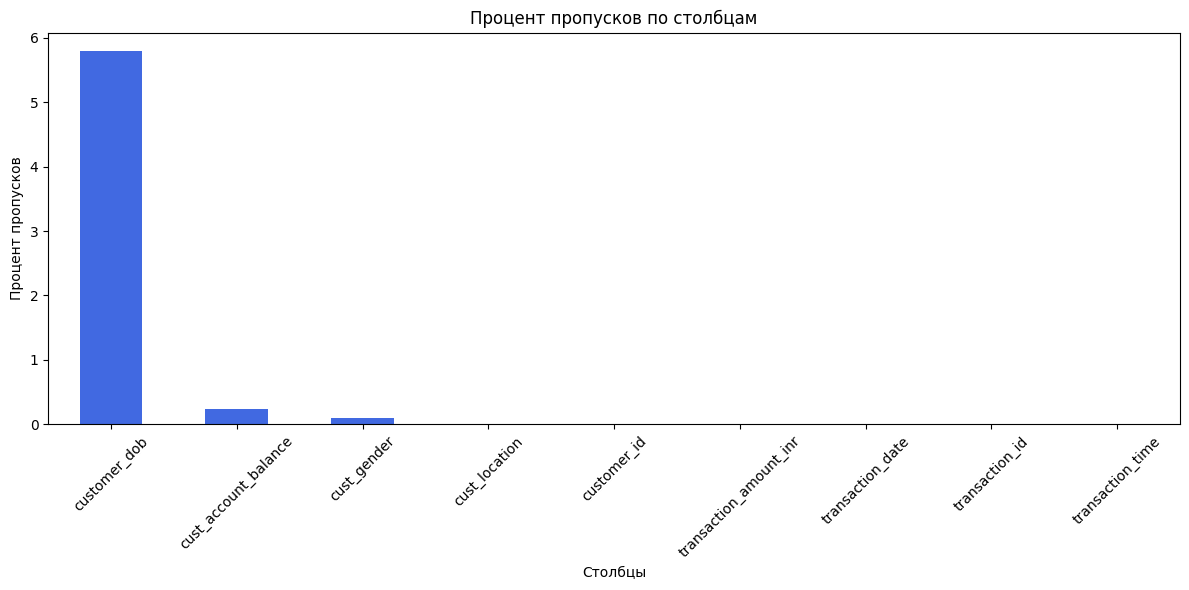


2. АНАЛИЗ ПАТТЕРНОВ ПРОПУСКОВ:
Корреляция пропусков между столбцами:


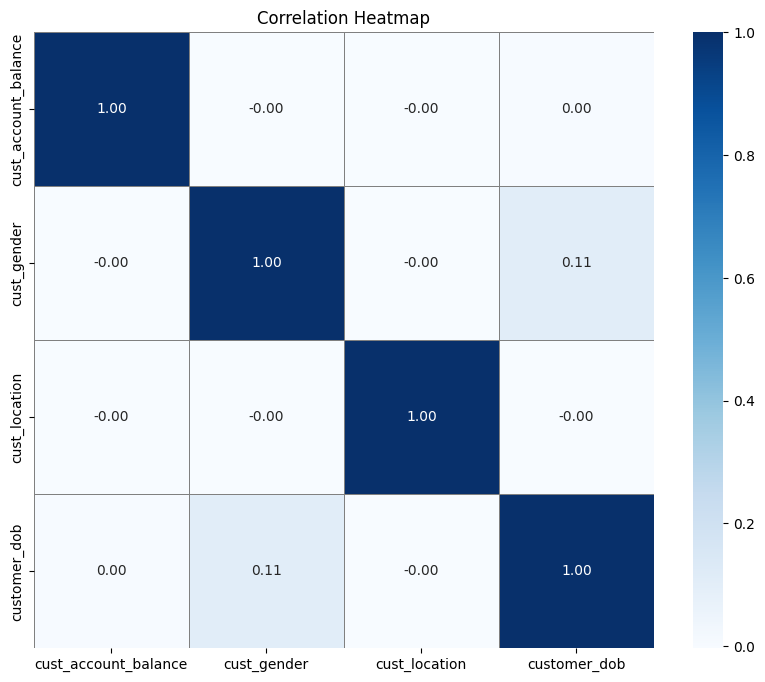


Строк с хотя бы одним пропуском: 63,245 (6.03%)

Примеры строк с пропусками:
   transaction_id customer_id customer_dob cust_gender  \
16            T17    C1376215          NaT           M   
22            T23    C7018081          NaT           M   
28            T29    C7935438          NaT           M   
29            T30    C8736958   1986-12-19           M   
35            T36    C1211387          NaT           M   

               cust_location  cust_account_balance transaction_date  \
16                    MUMBAI              77495.15       2016-08-01   
22  WAYS PANCHKUVA AHMEDABAD                143.07       2016-08-03   
28                    MOHALI             969436.12       2016-08-03   
29  GRAM PANCHAYTH HYDERABAD                   NaN       2016-08-03   
35                 AHMEDABAD              11791.25       2016-08-03   

    transaction_time  transaction_amount_inr  
16            124727                 1423.11  
22            104718                  110.00  
28   

In [11]:
import matplotlib.pyplot as plt

print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")

# Базовый анализ пропусков
print("\n1. ОБЩАЯ ИНФОРМАЦИЯ О ПРОПУСКАХ:")

missing_stats = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Пропущено': missing_stats,
    'Процент': missing_percent,
    'Всего': len(df)
})

print(missing_df)

# Визуализация пропусков


plt.figure(figsize=(12, 6))

sorted_percent = missing_df['Процент'].sort_values(ascending=False)
sorted_percent.plot(kind='bar', color='royalblue')
plt.title('Процент пропусков по столбцам')
plt.xlabel('Столбцы')
plt.ylabel('Процент пропусков')
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()


# Анализ паттернов пропусков
print("\n2. АНАЛИЗ ПАТТЕРНОВ ПРОПУСКОВ:")

# Проверяем, связаны ли пропуски между столбцами
print("Корреляция пропусков между столбцами:")


cols_to_analyze = ['cust_account_balance', 'cust_gender', 'cust_location', 'customer_dob']
missing_corr = df[cols_to_analyze].isnull().corr()

import seaborn as sns
import matplotlib.pyplot as plt

# Построение тепловой карты корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(missing_corr, annot=True, cmap='Blues', fmt='.2f',
            linewidths=0.5, linecolor='gray')
plt.title('Correlation Heatmap')
plt.show()


# Поиск строк с пропусками
rows_with_missing = df.isnull().any(axis=1)
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_missing.sum():,} ({rows_with_missing.sum()/len(df)*100:.2f}%)")

# Детальный анализ строк с пропусками
if rows_with_missing.any():
    missing_rows_df = df[rows_with_missing]
    print(f"\nПримеры строк с пропусками:")
    print(missing_rows_df.head())



# Вывод
Для анализа по возрасту:\
Использовать только строки с заполненной датой рождения\
Для анализа баланса:\
Отдельно анализировать подмножество с известным балансом\
Проверить источник данных:\
Уточнить, являются ли пропуски системными (например, данные не собирались до определённой даты) или случайными.

In [12]:
# 1. Локация и Пол (Категориальные данные, пропусков мало: 0.01% и 0.10%)
# Удаляем строки с пропусками
df = df.dropna(subset=['cust_location'])
df = df.dropna(subset=['cust_gender'])

# 2. Баланс счета (Количественные данные, 0.23%)
# Удаляем строки с пропусками
df = df.dropna(subset=['cust_account_balance'])

# 3. Дата рождения (Много пропусков: 5.79%)
# Простое заполнение средней датой может создать ложный пик в данных.
# Удаляем строки с пропусками
df = df.dropna(subset=['customer_dob'])

# Проверка результата
print(df.isnull().sum())


transaction_id            0
customer_id               0
customer_dob              0
cust_gender               0
cust_location             0
cust_account_balance      0
transaction_date          0
transaction_time          0
transaction_amount_inr    0
dtype: int64


In [13]:
print(f"Количество строк в DataFrame: {len(df):,}")
print(f"Количество уникальных пользователей: {df['customer_id'].nunique():,}")

Количество строк в DataFrame: 985,322
Количество уникальных пользователей: 839,081


In [14]:
# Текущая дата для расчета возраста
current_date = pd.Timestamp.now()

# Расчет возраста в годах (с точностью до дней)
df['age_years'] = ((current_date - df['customer_dob']).dt.days / 365.25).round(2)
# Расчет возраста в целых годах
df['age_int'] = (current_date.year - df['customer_dob'].dt.year)
# Оставляем только корректные данные
df = df[(df['age_years'] >= 0) & (df['age_years'] <= 120)]
# Создаем DataFrame с уникальными клиентами и их возрастом
unique_customers = df.drop_duplicates('customer_id')[['customer_id', 'age_int', 'age_years', 'customer_dob']]

print(f"Всего уникальных клиентов: {unique_customers['customer_id'].nunique():,}")

Всего уникальных клиентов: 799,649


In [15]:
print(f"Количество строк в DataFrame: {len(df):,}")
print(f"Количество уникальных пользователей: {df['customer_id'].nunique():,}")

Количество строк в DataFrame: 931,212
Количество уникальных пользователей: 799,649


# Исследовательский анализ данных

In [16]:
# сколько уникальных клиентов?
unique_customers_count = df['customer_id'].nunique()
print(f"Количество уникальных клиентов: {unique_customers_count:}")

Количество уникальных клиентов: 799649


Количество уникальных клиентов по месяцам:
transaction_date
2016-08    525791
2016-09    329001
2016-10      3235
Name: customer_id, dtype: int64


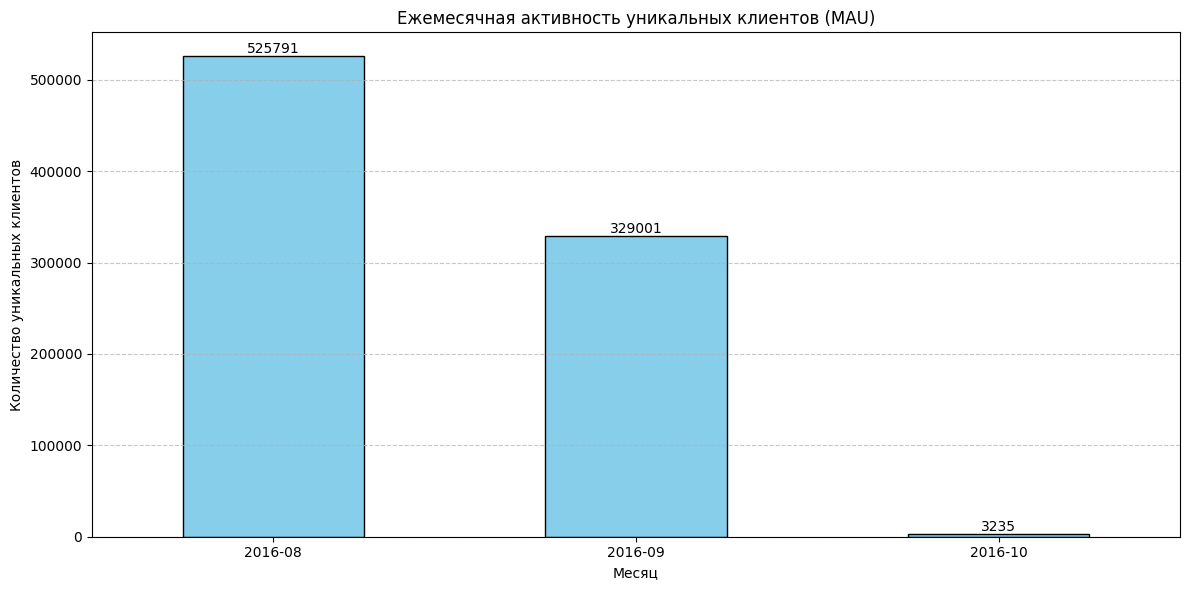

In [17]:
# 2. Группировка по месяцу и подсчет уникальных customer_id
monthly_unique_customers = df.groupby(df['transaction_date'].dt.to_period('M'))['customer_id'].nunique()

# Преобразуем индекс обратно в строковый формат для удобства печати и графиков
monthly_unique_customers.index = monthly_unique_customers.index.astype(str)

print("Количество уникальных клиентов по месяцам:")
print(monthly_unique_customers)

# 3. Визуализация
plt.figure(figsize=(12, 6))
bars = monthly_unique_customers.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Ежемесячная активность уникальных клиентов (MAU)')
plt.xlabel('Месяц')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Добавление подписей над столбцами
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,  # +5 для приподнимания
             int(bar.get_height()),
             ha='center', va='bottom', fontsize=10)

plt.show()



Спад на 99% за один месяц статистически маловероятен для здорового бизнеса и почти наверняка указывает на проблему с данными или методологией расчёта. Прежде чем делать бизнес-выводы, необходимо верифицировать корректность исходных данных за октябрь 2016 г. Без этой проверки любые интерпретации будут некорректными.

In [18]:
# какое количество транзакций было совершено?
total_transactions = len(df)
print(f"Общее количество транзакций: {total_transactions:.0f}")

Общее количество транзакций: 931212


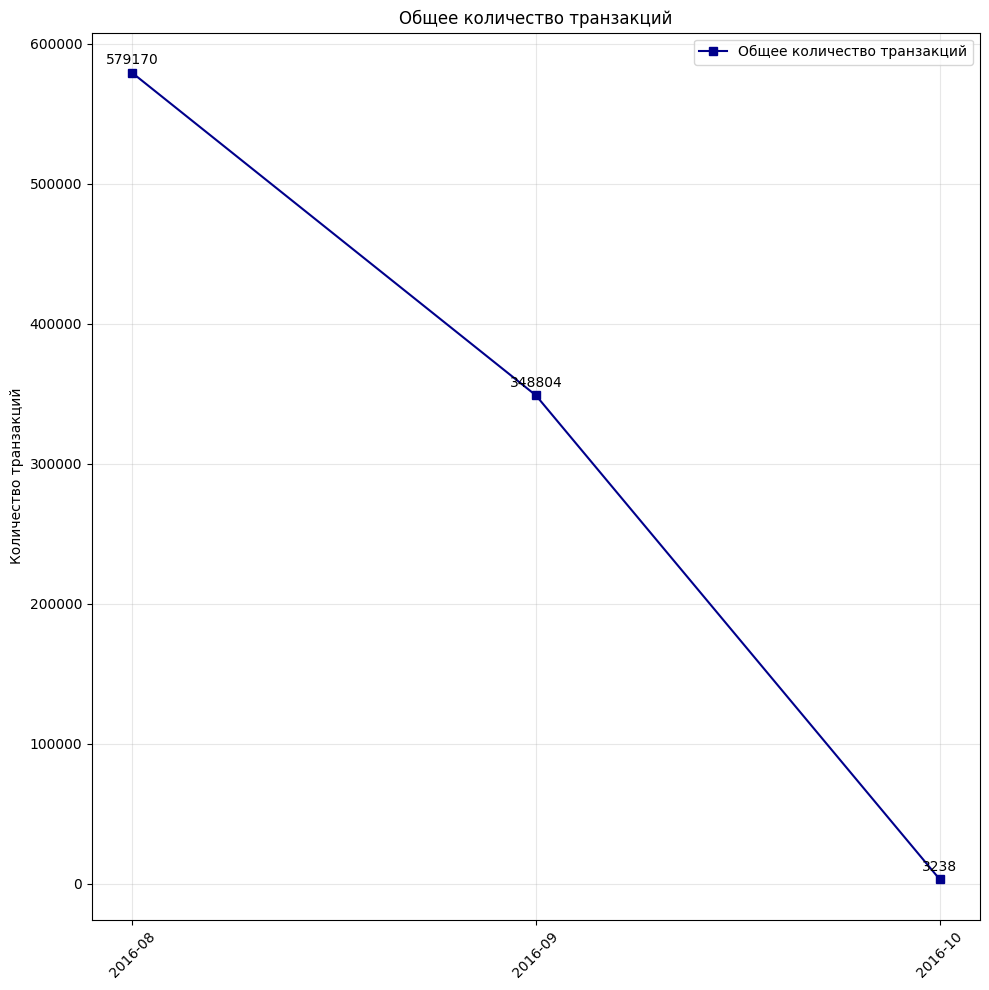

In [20]:
import matplotlib.pyplot as plt

# Группируем по месяцам и агрегируем данные
monthly_stats = df.groupby(df['transaction_date'].dt.to_period('M')).agg(
    total_transactions=('transaction_id', 'count'),
    unique_customers=('customer_id', 'nunique')
)

# Построение линейного графика для общего количества транзакций
plt.figure(figsize=(10, 10))
plt.plot(monthly_stats.index.astype(str), monthly_stats['total_transactions'], marker='s', color='darkblue',
         label='Общее количество транзакций')
plt.title('Общее количество транзакций')
plt.ylabel('Количество транзакций')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Добавление подписей над точками
for x, y in zip(monthly_stats.index.astype(str), monthly_stats['total_transactions']):
    plt.text(x, y + 4000,
             int(y),
             ha='center', va='bottom', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()



In [19]:
# сколько в среднем транзакций приходится на одного клиента?
avg_transactions_per_customer = total_transactions / unique_customers_count
print(f"Среднее количество транзакций на клиента: {avg_transactions_per_customer:.2f}")

Среднее количество транзакций на клиента: 1.16


In [22]:
# Считаем среднее количество транзакций на одного уникального клиента в месяц
monthly_stats['tx_per_customer'] = monthly_stats['total_transactions'] / monthly_stats['unique_customers']

# Для удобства отображения преобразуем индекс в строку
monthly_stats.index = monthly_stats.index.astype(str)

print("Ежемесячная статистика:")
print(monthly_stats)


Ежемесячная статистика:
                  total_transactions  unique_customers  tx_per_customer
transaction_date                                                       
2016-08                       579170            525791         1.101521
2016-09                       348804            329001         1.060191
2016-10                         3238              3235         1.000927


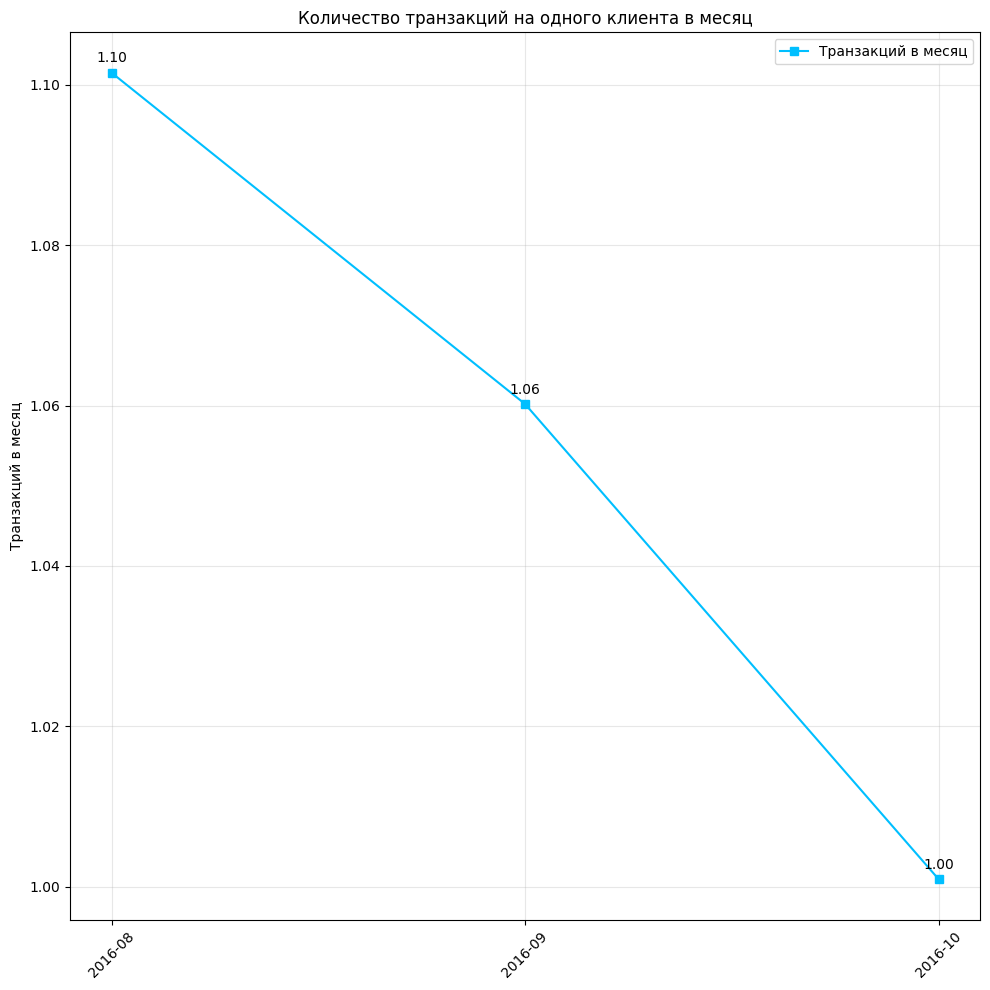

In [23]:
# Построение количества транзакций на одного уникального клиента в месяц
plt.figure(figsize=(10, 10))
plt.plot(monthly_stats.index.astype(str), monthly_stats['tx_per_customer'], marker='s', color='deepskyblue',
         label='Транзакций в месяц')
plt.title('Количество транзакций на одного клиента в месяц')
plt.ylabel('Транзакций в месяц')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Добавление подписей над точками
for x, y in zip(monthly_stats.index.astype(str), monthly_stats['tx_per_customer']):
    plt.text(x, y + 0.0009,
             f"{y:.2f}",
             ha='center', va='bottom', fontsize=10)



plt.legend()
plt.tight_layout()
plt.show()

На основе предоставленной ежемесячной статистики можно сделать несколько выводов:

1. Общее количество транзакций: В августе 2016 года было зафиксировано 579177 транзакций, что значительно больше, чем в сентябре (348806) и октябре (3238). Это может указывать на сезонный рост активности в августе или на какие-то специальные мероприятия или акции, которые могли привлечь больше клиентов.

2. Количество уникальных клиентов: Число уникальных клиентов также было наивысшим в августе (525796), затем снизилось в сентябре (329003) и резко упало в октябре (3235). Это может свидетельствовать о том, что после пикового месяца многие клиенты не вернулись для повторных покупок, что может быть проблемой для бизнеса.

3. Среднее количество транзакций на клиента: Показатель tx_per_customer (транзакции на клиента) показывает, что в августе этот показатель составил 1.10, что говорит о том, что в среднем каждый клиент совершал чуть больше одной транзакции. В сентябре этот показатель немного снизился до 1.06, а в октябре — до 1.00, что может указывать на снижение лояльности клиентов или уменьшение интереса к продуктам/услугам.

Рекомендации:
* Необходимо проанализировать причины резкого снижения как общего количества транзакций, так и числа уникальных клиентов в сентябре и особенно в октябре.
* Рассмотреть возможность внедрения программ лояльности или акций, направленных на удержание клиентов и стимулирование повторных покупок.
* Провести дополнительные исследования для выявления факторов, влияющих на активность клиентов в разные месяцы.

В целом, данные указывают на необходимость внимательного анализа клиентской базы и стратегий привлечения и удержания клиентов.

In [22]:
# изучить распределение и размах величин CustAccountBalance и TransactionAmount
import pandas as pd

# Выбираем нужные столбцы
cols = ['cust_account_balance', 'transaction_amount_inr']

# Основные статистические показатели
distribution_stats = df[cols].describe(percentiles=[.05, .25, .5, .75, .95, .99])

print("Анализ распределения величин:")
print(distribution_stats)

# Размах
for col in cols:
    range_val = df[col].max() - df[col].min()
    print(f"\nРазмах для {col}: {range_val:,.2f}")


Анализ распределения величин:
       cust_account_balance  transaction_amount_inr
count          9.312120e+05            9.312120e+05
mean           8.752639e+04            1.355196e+03
std            4.541223e+05            5.820840e+03
min            0.000000e+00            0.000000e+00
5%             6.483000e+01            2.900000e+01
25%            4.372260e+03            1.500000e+02
50%            1.517926e+04            4.040000e+02
75%            4.948524e+04            1.056507e+03
95%            3.319561e+05            4.601000e+03
99%            1.174823e+06            1.610300e+04
max            6.138221e+07            1.560035e+06

Размах для cust_account_balance: 61,382,213.47

Размах для transaction_amount_inr: 1,560,034.99


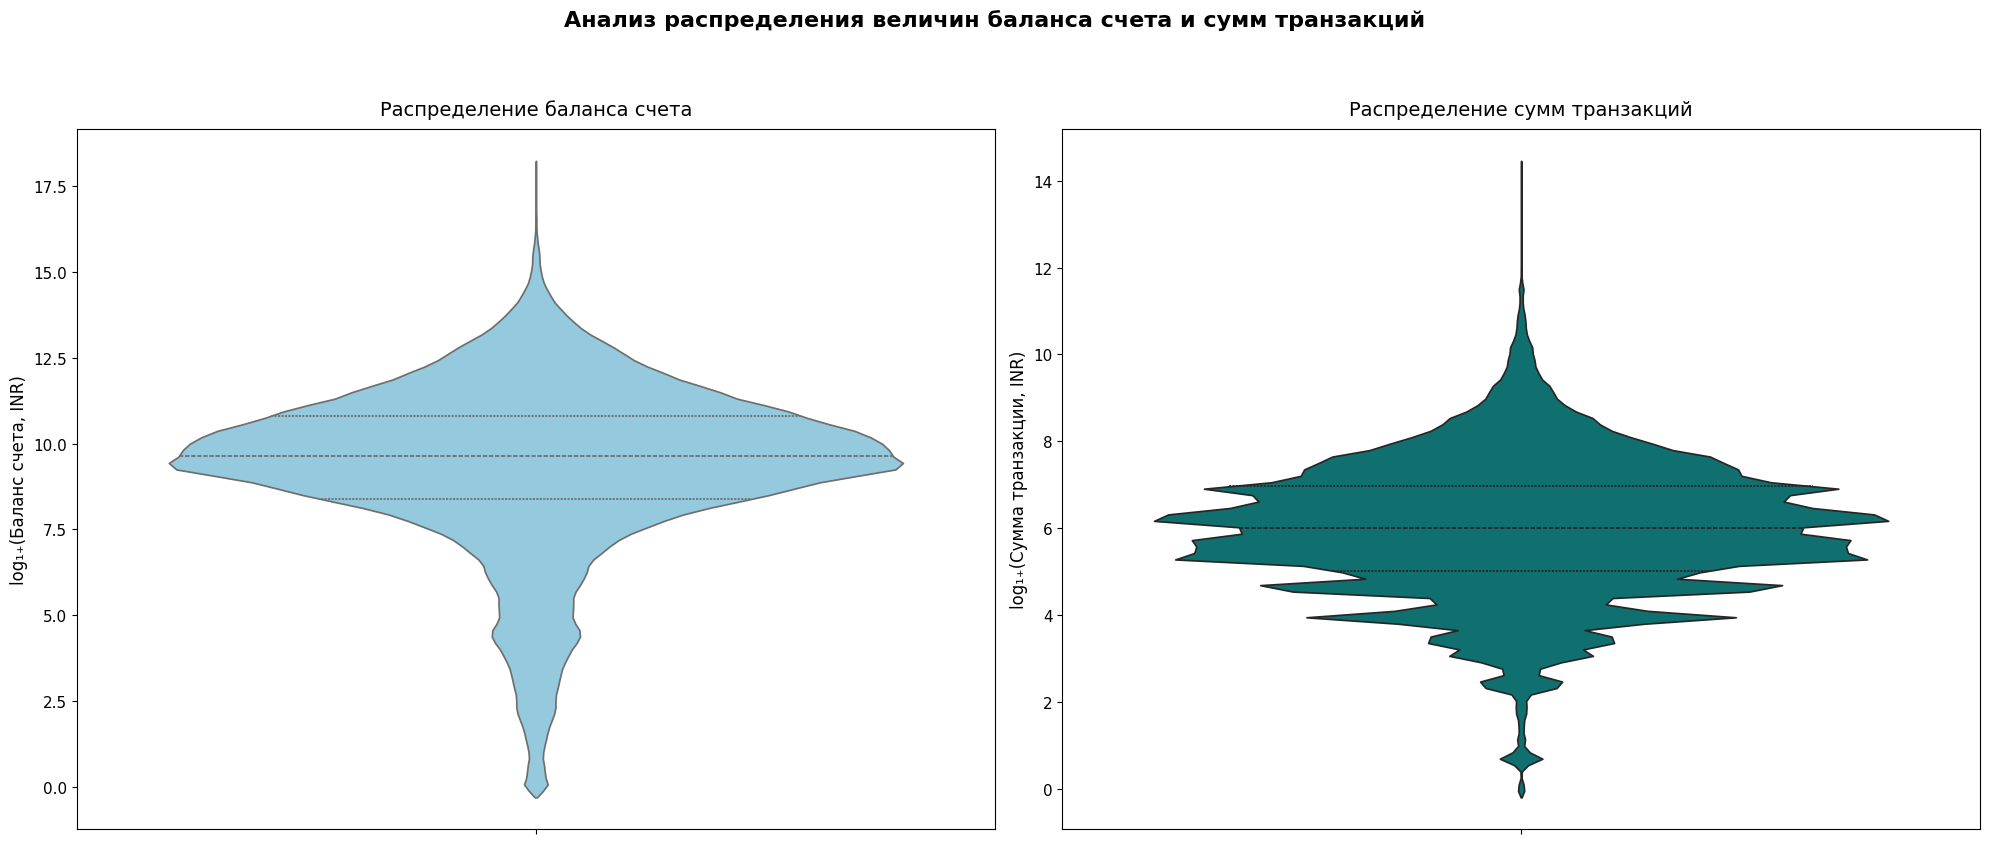

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Выбираем нужные столбцы
cols = ['cust_account_balance', 'transaction_amount_inr']
plot_data = df[cols]

# Создание графиков: 1 строка, 2 столбца
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # Изменено: (1, 2) вместо (2,)
fig.suptitle(
    'Анализ распределения величин баланса счета и сумм транзакций',
    fontsize=16,
    fontweight='bold',
    y=1.05  # Слегка увеличен отступ для заголовка
)

# График для баланса счета (логарифмированное)
sns.violinplot(
    y=np.log1p(plot_data['cust_account_balance']),
    ax=axes[0],
    color="skyblue",
    inner="quartile"
)
axes[0].set_title('Распределение баланса счета', fontsize=14, pad=10)
axes[0].set_ylabel('log₁₊(Баланс счета, INR)', fontsize=12)
axes[0].set_xlabel('')  # Убираем пустую подпись оси X

# График для сумм транзакций (логарифмированное)
sns.violinplot(
    y=np.log1p(plot_data['transaction_amount_inr']),
    ax=axes[1],
    color="teal",
    inner="quartile"
)
axes[1].set_title('Распределение сумм транзакций', fontsize=14, pad=10)
axes[1].set_ylabel('log₁₊(Сумма транзакции, INR)', fontsize=12)
axes[1].set_xlabel('')  # Убираем пустую подпись оси X

# Улучшаем читаемость подписей осей Y
for ax in axes:
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Дополнительный отступ под общим заголовком
plt.show()
plt.close()

На основе представленных данных о распределении величин "cust_account_balance" (баланс счета клиента) и "transaction_amount_inr" (сумма транзакции в индийских рупиях) можно сделать следующие выводы:

▎Выводы:

1. Общий обзор:
   – В выборке содержится 931,221 записей, что позволяет считать результаты статистически значимыми.

2. Баланс счета клиента (cust_account_balance):\
   – Среднее значение: 87,527.50 INR, что указывает на средний баланс
клиентов.\
   – Стандартное отклонение: 454,120.69 INR, что говорит о высокой вариативности в балансе клиентов.\
   – Минимальное значение: 0.00 INR, что может указывать на наличие клиентов с нулевым балансом.\
   – Максимальное значение: 61,382,213.47 INR, что свидетельствует о наличии очень состоятельных клиентов.\
   – Размах: 61,382,213.47 INR, что подтверждает значительное рассеяние данных и наличие выбросов.\
   – Квартильные значения: Примечательно, что 25% клиентов имеют баланс менее 4,372.35 INR, а 50% (медиана) имеют баланс менее 15,179.26 INR. Это может указывать на то, что большая часть клиентов имеет относительно низкие балансы.

3. Сумма транзакции (transaction_amount_inr):\
   – Среднее значение: 1,355.24 INR, что указывает на среднюю сумму транзакции.\
   – Стандартное отклонение: 5,820.88 INR, что также говорит о значительной вариативности в размерах транзакций.\
   – Минимальное значение: 0.00 INR, что может указывать на наличие транзакций с нулевой суммой.\
   – Максимальное значение: 1,560,034.99 INR, что свидетельствует о наличии крупных транзакций.\
   – Размах: 1,560,034.99 INR, что также подтверждает наличие выбросов и значительное разнообразие в размерах транзакций.\
   – Квартильные значения: 25% транзакций составляют менее 150.00 INR, а медиана равна 404.00 INR, что указывает на то, что большинство транзакций имеют небольшие суммы.

▎Заключение:

Данные показывают высокую вариативность как в балансе счетов клиентов, так и в суммах транзакций. Наличие значительных разрывов между квартилями и высоких максимальных значений указывает на существование как малых, так и крупных клиентов и транзакций. Это может быть полезной информацией для дальнейшего анализа клиентского сегмента и разработки стратегий обслуживания различных групп клиентов. Рекомендуется проводить дополнительные исследования для выявления причин такой вариативности и возможного влияния на бизнес-процессы.

In [ ]:
# изучить возраст клиентов (визуализировать)

In [24]:
print(f"Количество строк в DataFrame: {len(df):,}")
print(f"Количество уникальных пользователей: {df['customer_id'].nunique():,}")

Количество строк в DataFrame: 931,212
Количество уникальных пользователей: 799,649


In [25]:
# Анализ распределения возраста
print("СТАТИСТИКА ВОЗРАСТА КЛИЕНТОВ")
age_data = df['age_int']

print("\nОсновные статистики:")
print(f"Средний возраст: {age_data.mean():.1f} лет")
print(f"Медианный возраст: {age_data.median():.1f} лет")
print(f"Стандартное отклонение: {age_data.std():.1f} лет")
print(f"Минимальный возраст: {age_data.min():.0f} лет")
print(f"Максимальный возраст: {age_data.max():.0f} лет")
print(f"Размах: {age_data.max() - age_data.min():.0f} лет")

print("\nКвартили:")
print(f"25-й перцентиль (Q1): {age_data.quantile(0.25):.0f} лет")
print(f"50-й перцентиль (Медиана): {age_data.quantile(0.5):.0f} лет")
print(f"75-й перцентиль (Q3): {age_data.quantile(0.75):.0f} лет")

print("\nРаспределение по возрастным группам:")
age_bins = [0, 20, 30, 40, 50, 60]
age_labels = ['<20', '20-29', '30-39', '40-49', '50+']

#age_bins = [0, 18, 25, 35, 45, 55, 120]
#age_labels = ['До 18', '18-24', '25-34', '35-44', '45-54', '55+']
df['age_group'] = pd.cut(df['age_int'], bins=age_bins, labels=age_labels, right=False)

age_group_counts = df['age_group'].value_counts().sort_index()
for group, count in age_group_counts.items():
    percentage = count / len(df) * 100
    print(f"  {group}: {count:} клиентов ({percentage:.1f}%)")

СТАТИСТИКА ВОЗРАСТА КЛИЕНТОВ

Основные статистики:
Средний возраст: 39.5 лет
Медианный возраст: 38.0 лет
Стандартное отклонение: 6.1 лет
Минимальный возраст: 0 лет
Максимальный возраст: 57 лет
Размах: 57 лет

Квартили:
25-й перцентиль (Q1): 35 лет
50-й перцентиль (Медиана): 38 лет
75-й перцентиль (Q3): 43 лет

Распределение по возрастным группам:
  <20: 233 клиентов (0.0%)
  20-29: 10483 клиентов (1.1%)
  30-39: 523457 клиентов (56.2%)
  40-49: 319011 клиентов (34.3%)
  50+: 78028 клиентов (8.4%)


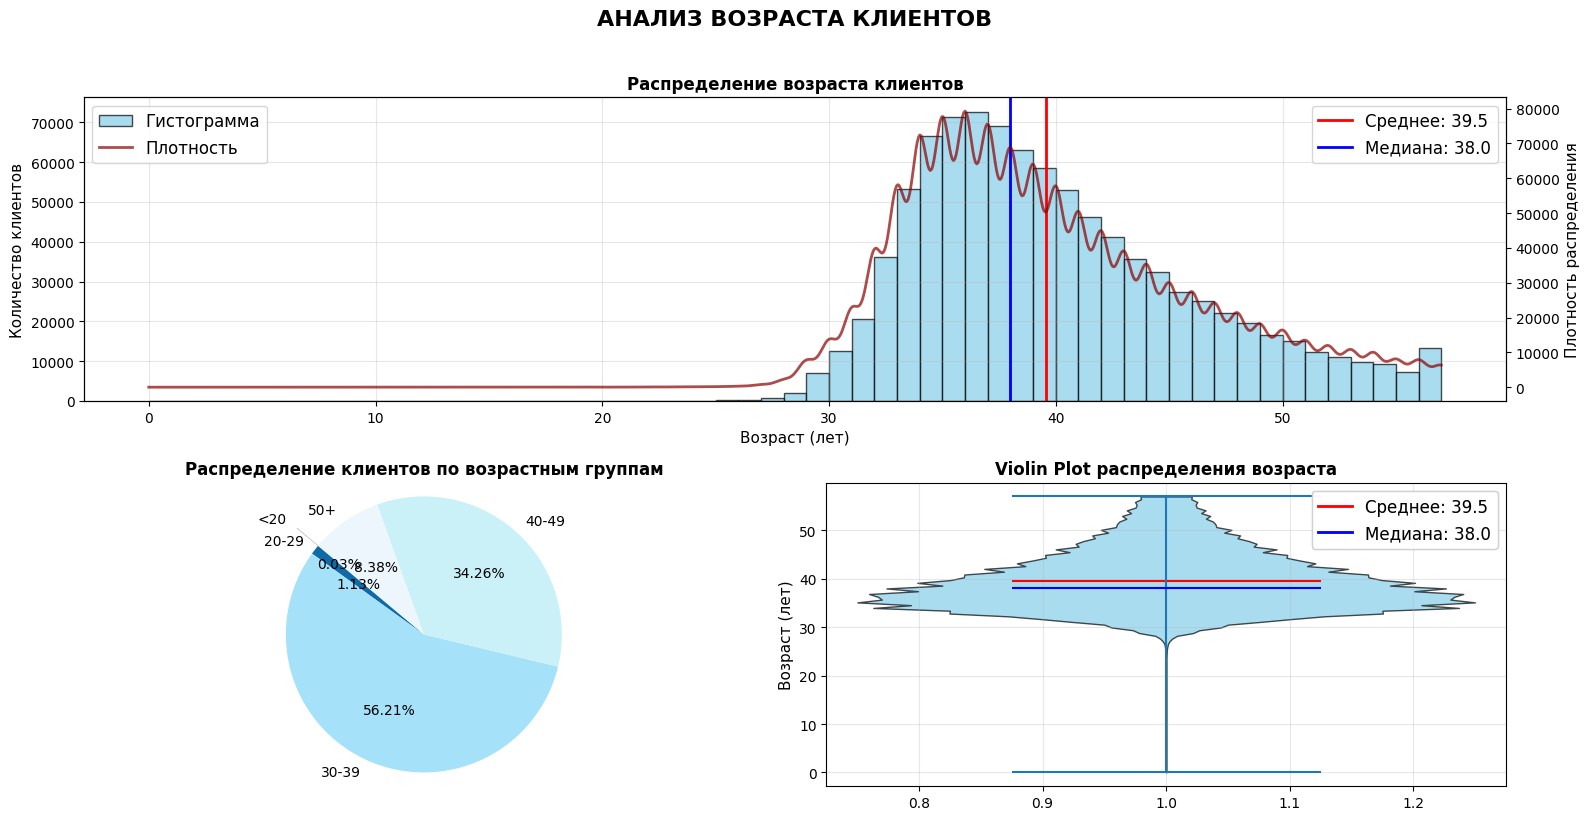

In [26]:
# СОЗДАЕМ ОКНО С ГРАФИКАМИ
fig = plt.figure(figsize=(16, 8))
fig.suptitle('АНАЛИЗ ВОЗРАСТА КЛИЕНТОВ', fontsize=16, fontweight='bold', y=1.02)

# 1. ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ ВОЗРАСТА
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. Построение основных элементов
ax1 = plt.subplot(2, 2, (1,2))
# Рисуем гистограмму и сохраняем для легенды слева
hist_patch = ax1.hist(age_data, bins=57, edgecolor='black', alpha=0.7, color='skyblue', label='Гистограмма')

# Рисуем линии среднего и медианы для легенды справа
line_mean = ax1.axvline(age_data.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {age_data.mean():.1f}')
line_median = ax1.axvline(age_data.median(), color='blue', linestyle='-', linewidth=2, label=f'Медиана: {age_data.median():.1f}')

# 2. Плотность (KDE)
kde = gaussian_kde(age_data)
x_range = np.linspace(age_data.min(), age_data.max(), 1000)
ax1_twin = ax1.twinx()
# Рисуем линию KDE и сохраняем для легенды слева
line_kde, = ax1_twin.plot(x_range, kde(x_range) * len(age_data), color='darkred', linewidth=2, alpha=0.7, label='Плотность (KDE)')

# --- СОЗДАНИЕ ДВУХ ЛЕГЕНД ---

# Легенда №1 (Справа): Среднее и Медиана
# Берем только 2-й и 3-й элементы из ax1 (линии)
legend_right = ax1.legend(handles=[line_mean, line_median], loc='upper right', fontsize=12)

# Легенда №2 (Слева): Гистограмма и Плотность
# Важно: используем ax1.add_artist, чтобы не затереть легенду справа
legend_left = ax1.legend(handles=[hist_patch[2][0], line_kde],
                         labels=['Гистограмма', 'Плотность'],
                         loc='upper left', fontsize=12)
ax1.add_artist(legend_right) # Возвращаем правую легенду на место

# Оформление осей
ax1.set_xlabel('Возраст (лет)', fontsize=11)
ax1.set_ylabel('Количество клиентов', fontsize=11)
ax1_twin.set_ylabel('Плотность распределения', fontsize=11)
ax1.set_title('Распределение возраста клиентов', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)


# 1. Подготовка данных
# Используем уже созданный вами объект age_group_counts
labels = age_group_counts.index
sizes = age_group_counts.values

# 2. Построение диаграммы
ax2 = plt.subplot(2, 2, 3)
ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%', # Показывает проценты на графике
    startangle=140,    # Поворачивает график для лучшего вида
    colors=['#000000','#0e6ba8', '#a6e1fa', '#caf0f8', '#edf6fc'],
    explode=(0.2, 0, 0, 0, 0) # Слегка отделяет первый сектор (<20)
)
ax2.set_title('Распределение клиентов по возрастным группам', fontsize=12, fontweight='bold')
ax2.axis('equal') # Делает круг идеально ровным

# 3. ВИОЛОНЧЕЛЬНЫЙ ГРАФИК
ax3 = plt.subplot(2, 2, 4)
violin_parts = ax3.violinplot(age_data, vert=True, showmeans=True, showmedians=True)
violin_parts['bodies'][0].set_facecolor('skyblue')
violin_parts['bodies'][0].set_edgecolor('black')
violin_parts['bodies'][0].set_alpha(0.7)
violin_parts['cmeans'].set_color('red')
violin_parts['cmedians'].set_color('blue')
ax3.set_ylabel('Возраст (лет)', fontsize=11)
ax3.set_title('Violin Plot распределения возраста', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
legend_right = ax3.legend(handles=[line_mean, line_median], loc='upper right', fontsize=12)
ax3.add_artist(legend_right)

plt.tight_layout()
plt.show()
plt.close()

▎Вывод по статистике возраста клиентов

Анализ возраста клиентов показывает, что средний возраст составляет 39.5 лет - большинство клиентов находятся в зрелом возрасте. Медианный возраст, равный 38.0 лет, подтверждает это, так как половина клиентов моложе этого значения, а другая половина — старше. Стандартное отклонение в 6.1 года свидетельствует о том, что возраст клиентов относительно однороден и не имеет значительных отклонений.

Возрастной диапазон варьируется от 0 до 57 лет, с размахом в 57 лет, что указывает на наличие как очень молодых, так и более зрелых клиентов. Однако стоит отметить, что минимальный возраст в 0 лет может указывать на наличие среди клиентов только что рождённых детей, которых зарегистрировали родители.

Квартили показывают, что 25% клиентов имеют возраст до 35 лет (Q1), а 75% клиентов — до 43 лет (Q3). Это также подтверждает, что основная масса клиентов сосредоточена в возрасте от 30 до 49 лет.

Распределение по возрастным группам демонстрирует, что наиболее значительная доля клиентов (56.2%) находится в возрастной категории 30-39 лет. Следующей по величине группой являются клиенты в возрасте 40-49 лет (34.3%). Возрастная группа 20-29 лет составляет всего 1.1%, а клиенты старше 50 лет составляют 8.4%. Интересно, что группа клиентов младше 20 лет очень мала.

В целом, данные показывают, что основная база клиентов компании состоит из людей среднего возраста (30-49 лет), что может быть важным фактором при разработке маркетинговых стратегий и продуктов, ориентированных на эту целевую аудиторию.

In [ ]:
# изучить пол клиентов (визуализировать)

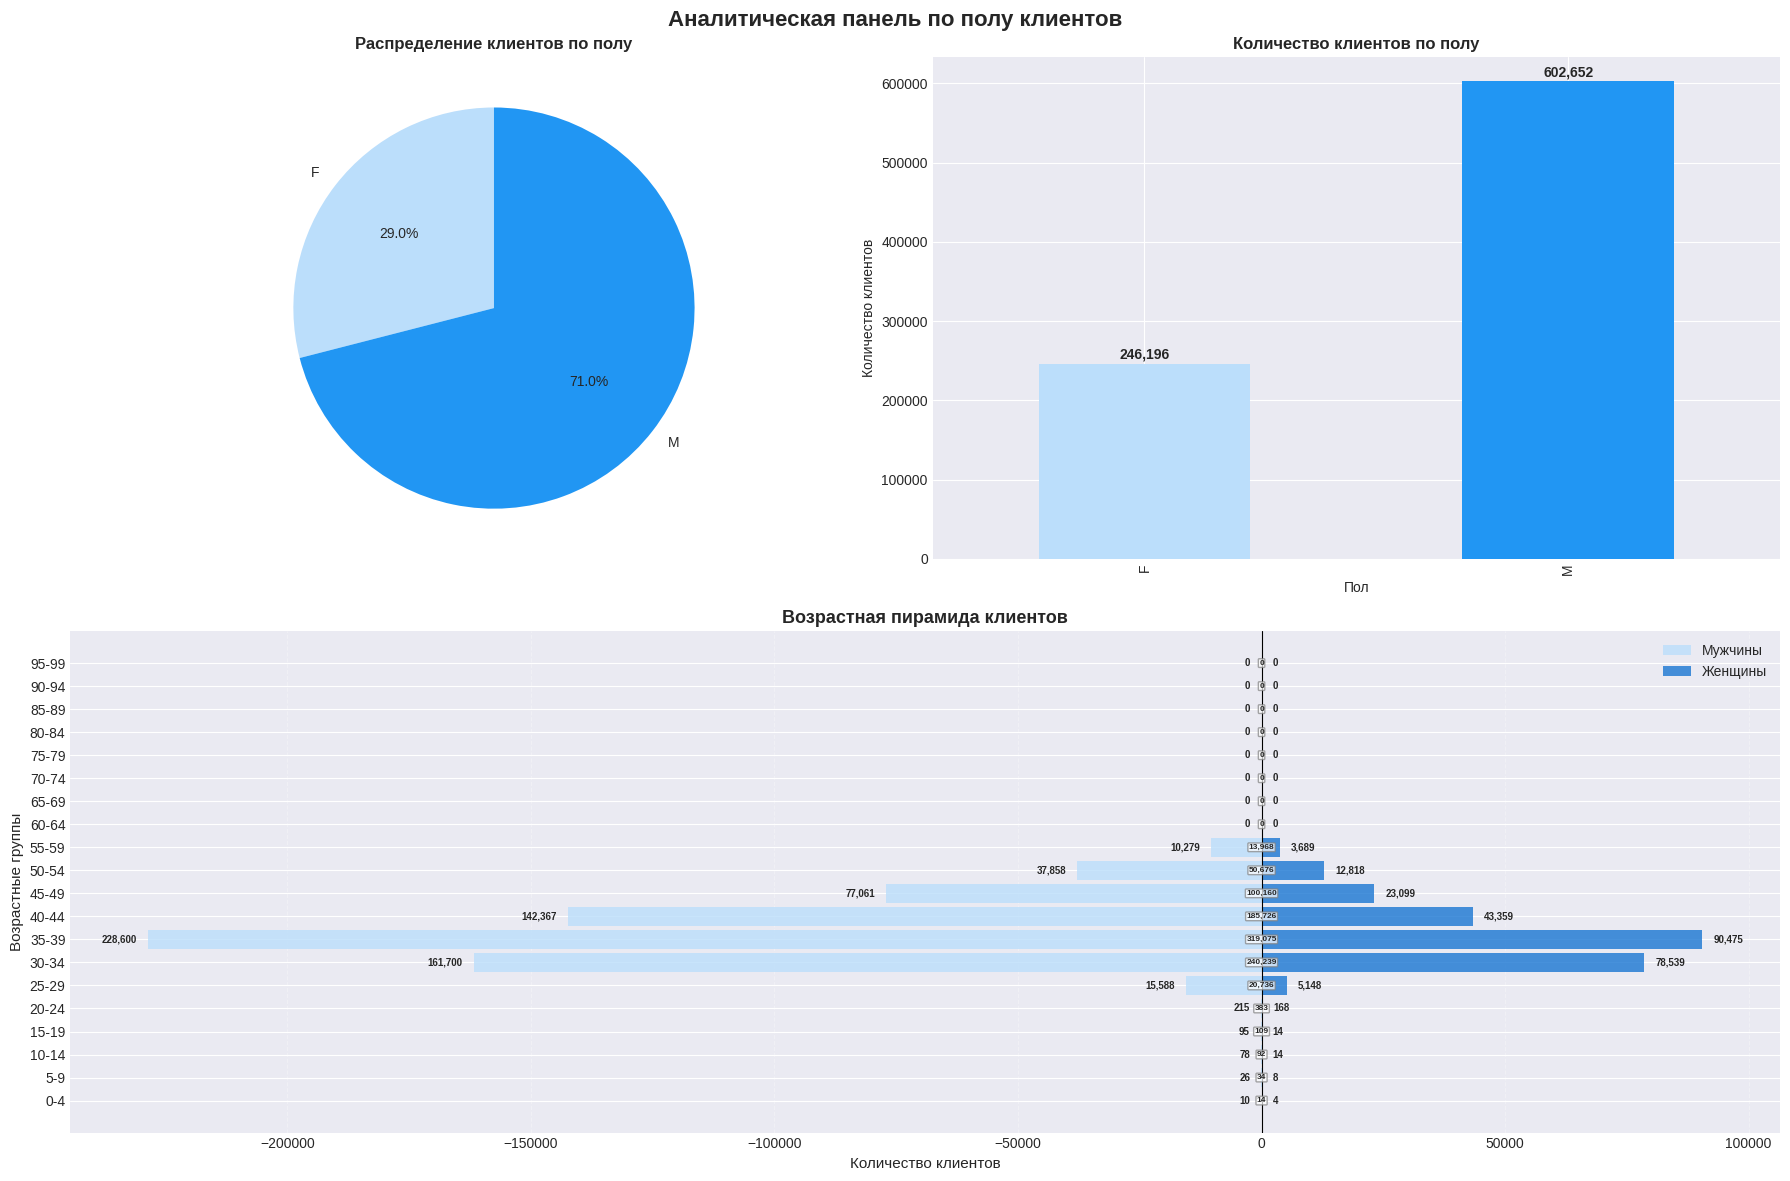


1. ОБЩАЯ СТАТИСТИКА:
   Всего клиентов: 799,649
   Мужчины (M): 602,652 (71.0%)
   Женщины (F): 246,196 (29.0%)
   Другие: 0 (0.0%)

2. ВОЗРАСТНАЯ СТАТИСТИКА ПО ПОЛУ:
   Мужчины:
     - Средний возраст: 39.4 лет
     - Медианный возраст: 38.3 лет
     - Возрастной диапазон: 0-57 лет
   Женщины:
     - Средний возраст: 38.6 лет
     - Медианный возраст: 37.1 лет
     - Возрастной диапазон: 1-57 лет

   Общая возрастная статистика:
     - Средний возраст всех клиентов: 39.2 лет
     - Медианный возраст всех клиентов: 38.0 лет
     - Минимальный возраст: 0 лет
     - Максимальный возраст: 57 лет

3. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ ПО ПОЛУ:
   Мужчины:
     - Средний баланс счета: 88,789.64
     - Средняя сумма транзакции: 1,298.89
     - Общая сумма транзакций: 875,292,192
     - Количество транзакций: 673,877
   Женщины:
     - Средний баланс счета: 84,218.33
     - Средняя сумма транзакции: 1,502.64
     - Общая сумма транзакций: 386,682,325
     - Количество транзакций: 257,335

   Сравнительны

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

# Создаем фигуру с 2x2 сеткой
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[1, 0].set_axis_off()  # график 3 (нижний левый)
axes[1, 1].set_axis_off()  # график 4 (нижний правый)
fig.suptitle('Аналитическая панель по полу клиентов', fontsize=16, fontweight='bold')

# 1. Базовая статистика по полу
# Получаем уникальных клиентов по полу
unique_customers_by_gender = df.groupby('cust_gender')['customer_id'].nunique()
gender_counts = unique_customers_by_gender
gender_percent = (unique_customers_by_gender / unique_customers_by_gender.sum()) * 100

# График 1: Круговой график распределения (верхний левый)
ax1 = axes[0, 0]
colors = ['#bbdefb', '#2196f3', '#64b5f6']
gender_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                   colors=colors[:len(gender_counts)], ax=ax1)
ax1.set_ylabel('')
ax1.set_title('Распределение клиентов по полу', fontweight='bold')

# График 2: Столбчатый график (верхний правый)
ax2 = axes[0, 1]
bars = gender_counts.plot(kind='bar', ax=ax2, color=['#bbdefb', '#2196f3'])
ax2.set_title('Количество клиентов по полу', fontweight='bold')
ax2.set_xlabel('Пол')
ax2.set_ylabel('Количество клиентов')

# Добавление значений над столбцами
for i, v in enumerate(gender_counts):
    ax2.text(i, v + gender_counts.max()*0.01, f'{v:,}',
             ha='center', fontweight='bold')

# График 3: Возрастная пирамида (занимает нижние две ячейки)
ax3 = fig.add_subplot(2, 2, (3, 4))  # Объединяем нижние две ячейки

# Создаем возрастные группы с шагом 5 лет для пирамиды
df['age_group_5'] = pd.cut(df['age_years'],
                           bins=range(0, 101, 5),
                           labels=[f'{i}-{i+4}' for i in range(0, 96, 5)])

# Фильтруем только M и F
gender_data = df[df['cust_gender'].isin(['M', 'F'])]

# Разделяем данные по полу
male_data = gender_data[gender_data['cust_gender'] == 'M']
female_data = gender_data[gender_data['cust_gender'] == 'F']

# Группируем по возрастным группам
male_counts = male_data['age_group_5'].value_counts().sort_index()
female_counts = female_data['age_group_5'].value_counts().sort_index()

# Создаем горизонтальную столбчатую диаграмму
y_pos = np.arange(len(male_counts))
ax3.barh(y_pos, -male_counts, color='#bbdefb', label='Мужчины', alpha=0.8)
ax3.barh(y_pos, female_counts, color='#1976d2', label='Женщины', alpha=0.8)

# Настройки графика
ax3.set_yticks(y_pos)
ax3.set_yticklabels(male_counts.index)
ax3.set_xlabel('Количество клиентов', fontsize=11)
ax3.set_ylabel('Возрастные группы', fontsize=11)
ax3.set_title('Возрастная пирамида клиентов', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right')

# Добавляем нулевую линию
ax3.axvline(0, color='black', linewidth=0.8)

# Добавляем значения на график
max_count = max(male_counts.max(), female_counts.max())
for i, (male, female) in enumerate(zip(male_counts, female_counts)):
    ax3.text(-male - max_count*0.01, i, f'{male:,}',
             va='center', ha='right', fontweight='bold', fontsize=7)
    ax3.text(female + max_count*0.01, i, f'{female:,}',
             va='center', ha='left', fontweight='bold', fontsize=7)

# Добавляем общее количество для каждой возрастной группы
for i, (male, female) in enumerate(zip(male_counts, female_counts)):
    total = male + female
    ax3.text(0, i, f'{total:,}',
             va='center', ha='center', fontweight='bold',
             backgroundcolor='white', fontsize=6, bbox=dict(boxstyle="round,pad=0.1",
                                                           facecolor='white',
                                                           edgecolor='gray',
                                                           alpha=0.7))

# Настройка сетки
ax3.grid(True, axis='x', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Выводим текстовую сводку в консоль

print(f"\n1. ОБЩАЯ СТАТИСТИКА:")
print(f"   Всего клиентов: {df['customer_id'].nunique():,}")
print(f"   Мужчины (M): {gender_counts.get('M', 0):,} ({gender_percent.get('M', 0):.1f}%)")
print(f"   Женщины (F): {gender_counts.get('F', 0):,} ({gender_percent.get('F', 0):.1f}%)")
others = gender_counts.sum() - gender_counts.get('M', 0) - gender_counts.get('F', 0)
others_percent = 100 - gender_percent.get('M', 0) - gender_percent.get('F', 0)
print(f"   Другие: {others:,} ({others_percent:.1f}%)")

print(f"\n2. ВОЗРАСТНАЯ СТАТИСТИКА ПО ПОЛУ:")
# Рассчитываем средний возраст по полу
age_stats = {}
for gender in ['M', 'F']:
    if gender in df['cust_gender'].values:
        age_stats[gender] = {
            'mean': df[df['cust_gender'] == gender]['age_years'].mean(),
            'median': df[df['cust_gender'] == gender]['age_years'].median(),
            'min': df[df['cust_gender'] == gender]['age_years'].min(),
            'max': df[df['cust_gender'] == gender]['age_years'].max()
        }

if 'M' in age_stats:
    print(f"   Мужчины:")
    print(f"     - Средний возраст: {age_stats['M']['mean']:.1f} лет")
    print(f"     - Медианный возраст: {age_stats['M']['median']:.1f} лет")
    print(f"     - Возрастной диапазон: {age_stats['M']['min']:.0f}-{age_stats['M']['max']:.0f} лет")

if 'F' in age_stats:
    print(f"   Женщины:")
    print(f"     - Средний возраст: {age_stats['F']['mean']:.1f} лет")
    print(f"     - Медианный возраст: {age_stats['F']['median']:.1f} лет")
    print(f"     - Возрастной диапазон: {age_stats['F']['min']:.0f}-{age_stats['F']['max']:.0f} лет")

print(f"\n   Общая возрастная статистика:")
print(f"     - Средний возраст всех клиентов: {df['age_years'].mean():.1f} лет")
print(f"     - Медианный возраст всех клиентов: {df['age_years'].median():.1f} лет")
print(f"     - Минимальный возраст: {df['age_years'].min():.0f} лет")
print(f"     - Максимальный возраст: {df['age_years'].max():.0f} лет")

print(f"\n3. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ ПО ПОЛУ:")
# Рассчитываем финансовые показатели по полу
finance_stats = {}
for gender in ['M', 'F']:
    if gender in df['cust_gender'].values:
        finance_stats[gender] = {
            'avg_balance': df[df['cust_gender'] == gender]['cust_account_balance'].mean(),
            'avg_transaction': df[df['cust_gender'] == gender]['transaction_amount_inr'].mean(),
            'total_transactions': df[df['cust_gender'] == gender]['transaction_amount_inr'].sum(),
            'transaction_count': df[df['cust_gender'] == gender]['transaction_amount_inr'].count()
        }

if 'M' in finance_stats:
    print(f"   Мужчины:")
    print(f"     - Средний баланс счета: {finance_stats['M']['avg_balance']:,.2f}")
    print(f"     - Средняя сумма транзакции: {finance_stats['M']['avg_transaction']:,.2f}")
    print(f"     - Общая сумма транзакций: {finance_stats['M']['total_transactions']:,.0f}")
    print(f"     - Количество транзакций: {finance_stats['M']['transaction_count']:,}")

if 'F' in finance_stats:
    print(f"   Женщины:")
    print(f"     - Средний баланс счета: {finance_stats['F']['avg_balance']:,.2f}")
    print(f"     - Средняя сумма транзакции: {finance_stats['F']['avg_transaction']:,.2f}")
    print(f"     - Общая сумма транзакций: {finance_stats['F']['total_transactions']:,.0f}")
    print(f"     - Количество транзакций: {finance_stats['F']['transaction_count']:,}")

# Сравнительная статистика
if 'M' in finance_stats and 'F' in finance_stats:
    balance_ratio = finance_stats['M']['avg_balance'] / finance_stats['F']['avg_balance'] if finance_stats['F']['avg_balance'] != 0 else 0
    transaction_ratio = finance_stats['M']['avg_transaction'] / finance_stats['F']['avg_transaction'] if finance_stats['F']['avg_transaction'] != 0 else 0
    print(f"\n   Сравнительные показатели М/Ж:")
    print(f"     - Отношение средних балансов: {balance_ratio:.2f}:1")
    print(f"     - Отношение средних транзакций: {transaction_ratio:.2f}:1")

print(f"\n4. ВОЗРАСТНАЯ СТРУКТУРА:")
print(f"   - Всего возрастных групп: {len(male_counts)} (с шагом 5 лет)")
print(f"   - Самая многочисленная мужская группа: {male_counts.idxmax()} ({male_counts.max():,} чел.)")
print(f"   - Самая многочисленная женская группа: {female_counts.idxmax()} ({female_counts.max():,} чел.)")

# Находим группу с максимальной разницей
max_diff_group = None
max_diff = 0
for group in male_counts.index:
    if group in female_counts.index:
        diff = abs(male_counts[group] - female_counts[group])
        if diff > max_diff:
            max_diff = diff
            max_diff_group = group

if max_diff_group:
    print(f"   - Группа с наибольшей разницей: {max_diff_group} (разница: {max_diff:,} чел.)")

# Общая статистика возрастной пирамиды
total_male = male_counts.sum()
total_female = female_counts.sum()
print(f"   - Всего мужчин в пирамиде: {total_male:,}")
print(f"   - Всего женщин в пирамиде: {total_female:,}")
print(f"   - Соотношение мужчин к женщинам: {total_male/total_female:.2f}:1" if total_female > 0 else "   - Соотношение: нет женщин для сравнения")

# Очистка временного столбца
df = df.drop('age_group_5', axis=1, errors='ignore')



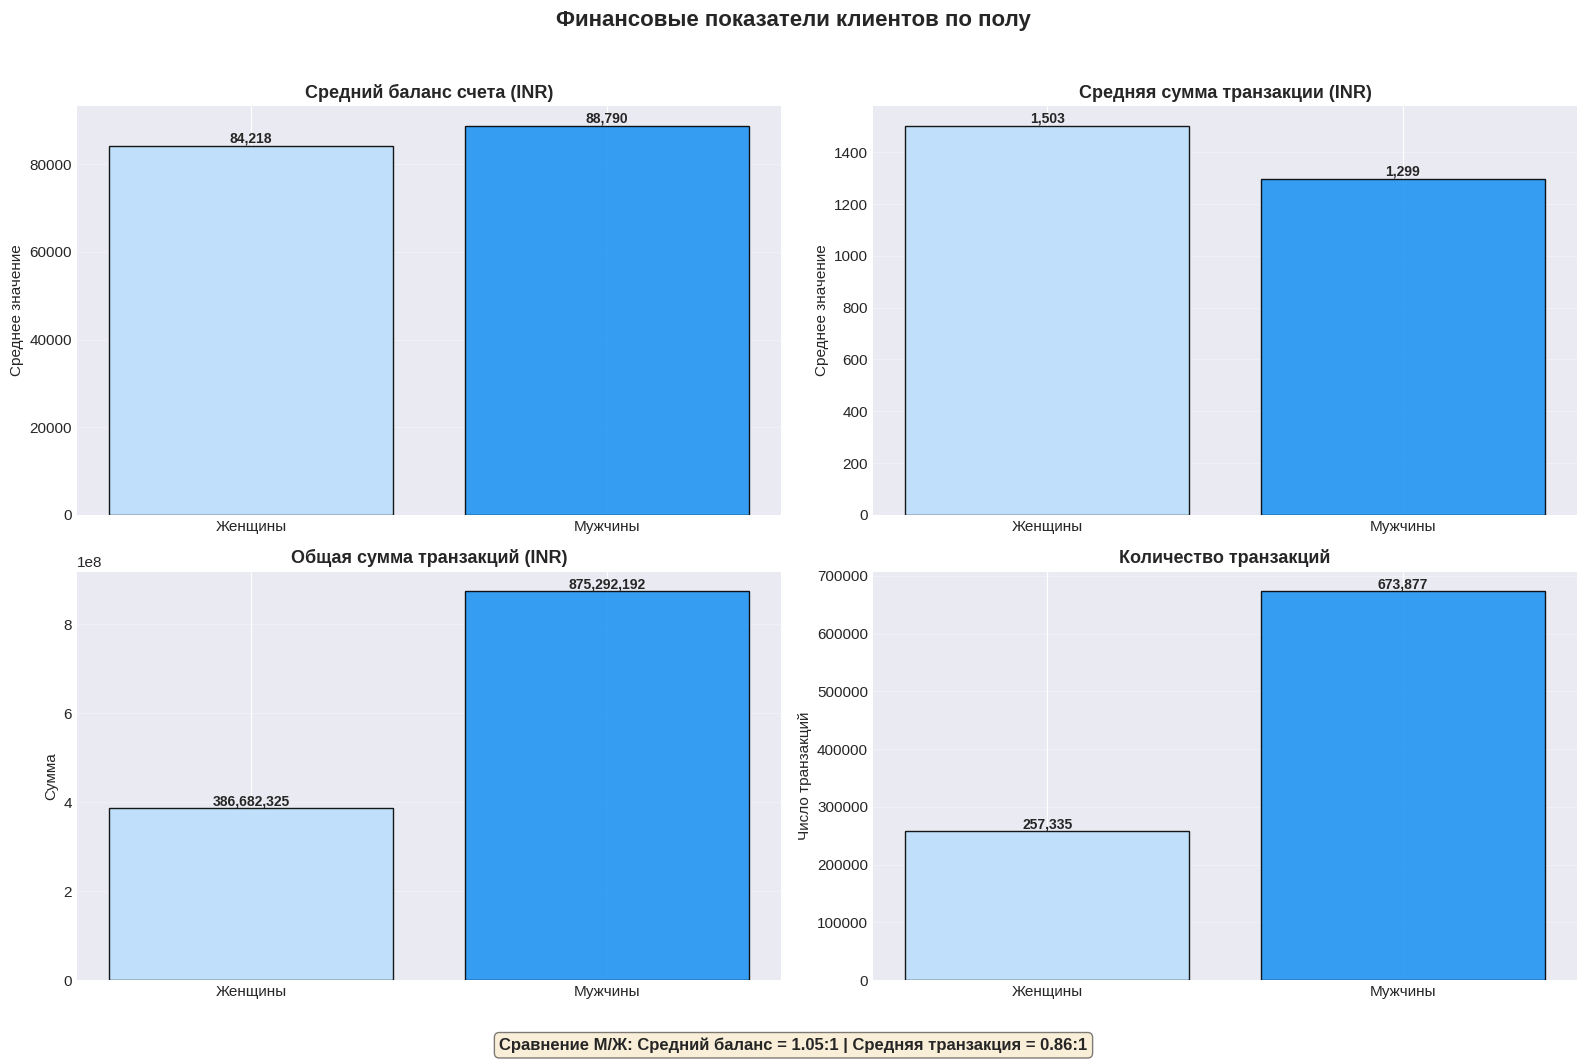

ФИНАНСОВЫЕ ПОКАЗАТЕЛИ ПО ПОЛУ (агрегация по транзакциям)

Женщины:
  • Средний баланс:        84,218.33 INR
  • Средняя транзакция:    1,502.64 INR
  • Общая сумма:           386,682,325 INR
  • Количество транзакций: 257,335

Мужчины:
  • Средний баланс:        88,789.64 INR
  • Средняя транзакция:    1,298.89 INR
  • Общая сумма:           875,292,192 INR
  • Количество транзакций: 673,877


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (16, 10)
sns.set_palette(['#bbdefb', '#2196f3'])
rcParams['font.size'] = 11

# Фильтрация данных: только M и F
df_gender = df[df['cust_gender'].isin(['M', 'F'])].copy()

# Агрегация финансовых метрик ПО ТРАНЗАКЦИЯМ (как в исходном коде)
finance_metrics = df_gender.groupby('cust_gender').agg(
    avg_balance=('cust_account_balance', 'mean'),
    avg_transaction=('transaction_amount_inr', 'mean'),
    total_transactions=('transaction_amount_inr', 'sum'),
    transaction_count=('transaction_amount_inr', 'count')
).reset_index()

# Переименование для подписей
finance_metrics['gender_label'] = finance_metrics['cust_gender'].map({'M': 'Мужчины', 'F': 'Женщины'})

# Создание сетки графиков 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Финансовые показатели клиентов по полу', fontsize=16, fontweight='bold', y=1.02)

# 1. Средний баланс счета
ax = axes[0, 0]
bars = ax.bar(
    finance_metrics['gender_label'],
    finance_metrics['avg_balance'],
    color=['#bbdefb', '#2196f3'],
    edgecolor='black',
    alpha=0.9
)
ax.set_title('Средний баланс счета (INR)', fontweight='bold', fontsize=13)
ax.set_ylabel('Среднее значение')
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{height:,.0f}',
        ha='center', va='bottom', fontweight='bold', fontsize=10
    )

# 2. Средняя сумма транзакции
ax = axes[0, 1]
bars = ax.bar(
    finance_metrics['gender_label'],
    finance_metrics['avg_transaction'],
    color=['#bbdefb', '#2196f3'],
    edgecolor='black',
    alpha=0.9
)
ax.set_title('Средняя сумма транзакции (INR)', fontweight='bold', fontsize=13)
ax.set_ylabel('Среднее значение')
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{height:,.0f}',
        ha='center', va='bottom', fontweight='bold', fontsize=10
    )

# 3. Общая сумма транзакций
ax = axes[1, 0]
bars = ax.bar(
    finance_metrics['gender_label'],
    finance_metrics['total_transactions'],
    color=['#bbdefb', '#2196f3'],
    edgecolor='black',
    alpha=0.9
)
ax.set_title('Общая сумма транзакций (INR)', fontweight='bold', fontsize=13)
ax.set_ylabel('Сумма')
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{height:,.0f}',
        ha='center', va='bottom', fontweight='bold', fontsize=10
    )

# 4. Количество транзакций
ax = axes[1, 1]
bars = ax.bar(
    finance_metrics['gender_label'],
    finance_metrics['transaction_count'],
    color=['#bbdefb', '#2196f3'],
    edgecolor='black',
    alpha=0.9
)
ax.set_title('Количество транзакций', fontweight='bold', fontsize=13)
ax.set_ylabel('Число транзакций')
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{height:,}',
        ha='center', va='bottom', fontweight='bold', fontsize=10
    )

# Добавление сравнительной подписи внизу
if len(finance_metrics) == 2:
    balance_ratio = finance_metrics.loc[finance_metrics['cust_gender']=='M', 'avg_balance'].values[0] / \
                   finance_metrics.loc[finance_metrics['cust_gender']=='F', 'avg_balance'].values[0]
    trans_ratio = finance_metrics.loc[finance_metrics['cust_gender']=='M', 'avg_transaction'].values[0] / \
                  finance_metrics.loc[finance_metrics['cust_gender']=='F', 'avg_transaction'].values[0]

    fig.text(
        0.5, -0.02,
        f"Сравнение М/Ж: Средний баланс = {balance_ratio:.2f}:1 | Средняя транзакция = {trans_ratio:.2f}:1",
        ha='center',
        fontsize=12,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

plt.tight_layout()
plt.subplots_adjust(bottom=0.05)  # Место для сравнительной подписи
plt.show()

# Дополнительно: вывод ключевых метрик в консоль (опционально)
print("="*60)
print("ФИНАНСОВЫЕ ПОКАЗАТЕЛИ ПО ПОЛУ (агрегация по транзакциям)")
print("="*60)
for _, row in finance_metrics.iterrows():
    print(f"\n{row['gender_label']}:")
    print(f"  • Средний баланс:        {row['avg_balance']:,.2f} INR")
    print(f"  • Средняя транзакция:    {row['avg_transaction']:,.2f} INR")
    print(f"  • Общая сумма:           {row['total_transactions']:,.0f} INR")
    print(f"  • Количество транзакций: {row['transaction_count']:,}")

▎Возрастная статистика

Данные показывают явное преобладание мужчин среди клиентов. Возрастная структура демонстрирует концентрацию клиентов в возрасте от 35 до 39 лет, что может указывать на активное участие данной возрастной группы в финансовых операциях. Финансовые показатели также свидетельствуют о высоком уровне активности мужчин в сравнении с женщинами, хотя женщины имеют более высокую среднюю сумму транзакции.

In [28]:
print(f"Количество строк в DataFrame: {len(df):,}")
print(f"Количество уникальных пользователей: {df['customer_id'].nunique():,}")

Количество строк в DataFrame: 931,212
Количество уникальных пользователей: 799,649


In [ ]:
# изучить место жительства клиентов (визуализировать)

СТАТИСТИКА ПО МЕСТУ ЖИТЕЛЬСТВА КЛИЕНТОВ (cust_location)

1. ОБЩАЯ ИНФОРМАЦИЯ О ЛОКАЦИЯХ
Общее количество уникальных локаций: 7,823
Общее количество уникальных клиентов: 799,649
Общее количество транзакций: 931,212

2. КОЛИЧЕСТВО КЛИЕНТОВ ПО ЛОКАЦИЯМ

Топ-20 локаций по количеству клиентов:
----------------------------------------------------------------------
№    Локация                                  Клиенты      Доля,%  
----------------------------------------------------------------------
1    MUMBAI                                   90,912        11.37%
2    BANGALORE                                73,472         9.19%
3    NEW DELHI                                69,292         8.67%
4    GURGAON                                  66,074         8.26%
5    DELHI                                    62,818         7.86%
6    NOIDA                                    30,184         3.77%
7    CHENNAI                                  25,098         3.14%
8    PUNE                      

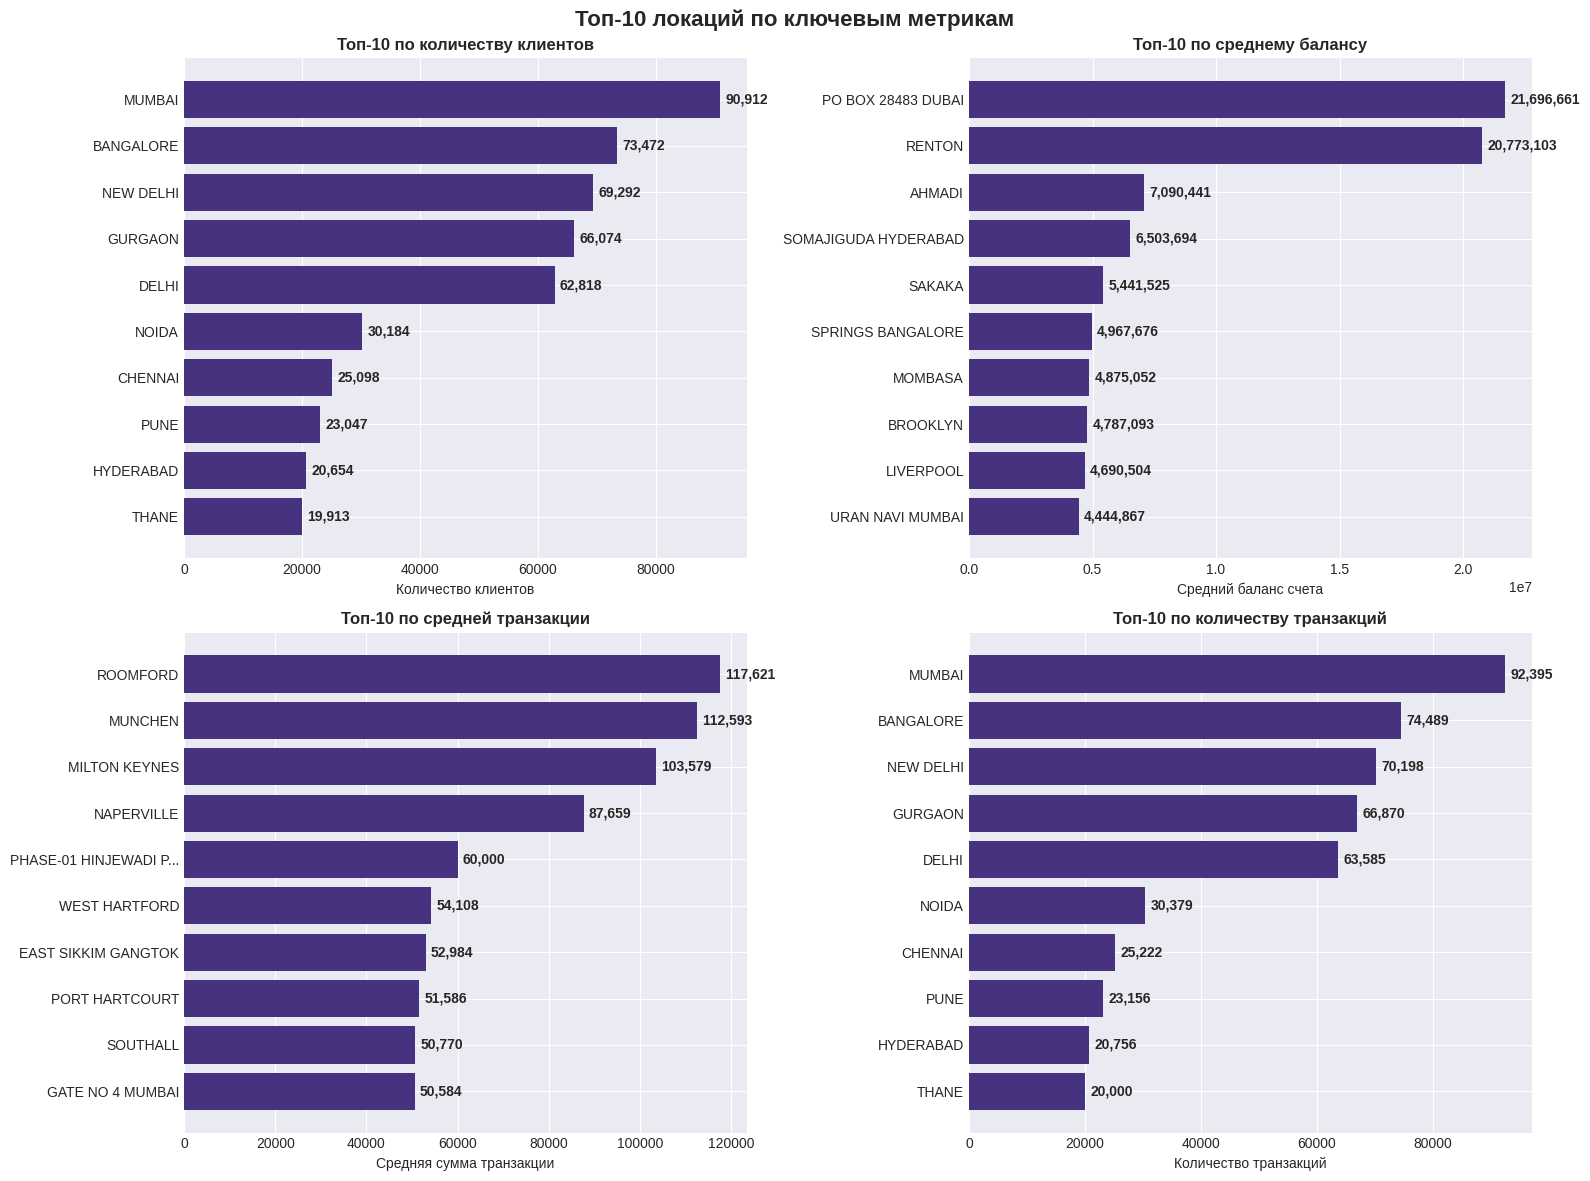

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 8)
sns.set_palette("viridis")

print("=" * 70)
print("СТАТИСТИКА ПО МЕСТУ ЖИТЕЛЬСТВА КЛИЕНТОВ (cust_location)")
print("=" * 70)

# 1. Общая статистика по локациям
print("\n" + "=" * 70)
print("1. ОБЩАЯ ИНФОРМАЦИЯ О ЛОКАЦИЯХ")
print("=" * 70)

total_locations = df['cust_location'].nunique()
total_clients = df['customer_id'].nunique()
total_transactions = len(df)

print(f"Общее количество уникальных локаций: {total_locations:,}")
print(f"Общее количество уникальных клиентов: {total_clients:,}")
print(f"Общее количество транзакций: {total_transactions:,}")

# 2. Количество клиентов по локациям
print("\n" + "=" * 70)
print("2. КОЛИЧЕСТВО КЛИЕНТОВ ПО ЛОКАЦИЯМ")
print("=" * 70)

# Количество уникальных клиентов по локациям
clients_by_location = df.groupby('cust_location')['customer_id'].nunique().sort_values(ascending=False)

print(f"\nТоп-20 локаций по количеству клиентов:")
print("-" * 70)
print(f"{'№':<4} {'Локация':<40} {'Клиенты':<12} {'Доля,%':<8}")
print("-" * 70)

for i, (location, count) in enumerate(clients_by_location.head(20).items(), 1):
    percent = (count / total_clients) * 100
    print(f"{i:<4} {location[:38]:<40} {count:<12,} {percent:>6.2f}%")

# Общая статистика
top_10_clients = clients_by_location.head(10).sum()
top_20_clients = clients_by_location.head(20).sum()
top_10_percent = (top_10_clients / total_clients) * 100
top_20_percent = (top_20_clients / total_clients) * 100

print("\n" + "-" * 70)
print(f"Клиенты в топ-10 локациях: {top_10_clients:,} ({top_10_percent:.1f}% от всех)")
print(f"Клиенты в топ-20 локациях: {top_20_clients:,} ({top_20_percent:.1f}% от всех)")

# 3. Средний баланс счета по локациям
print("\n" + "=" * 70)
print("3. СРЕДНИЙ БАЛАНС СЧЕТА ПО ЛОКАЦИЯМ (cust_account_balance)")
print("=" * 70)

# Средний баланс по локациям (по клиентам)
balance_by_location = df.groupby('cust_location')['cust_account_balance'].mean().sort_values(ascending=False)

print(f"\nТоп-20 локаций по среднему балансу счета:")
print("-" * 70)
print(f"{'№':<4} {'Локация':<40} {'Ср.баланс':<15}")
print("-" * 70)

for i, (location, balance) in enumerate(balance_by_location.head(20).items(), 1):
    print(f"{i:<4} {location[:38]:<40} {balance:>15,.2f}")

print(f"\nТоп-20 локаций по минимальному балансу счета:")
print("-" * 70)
print(f"{'№':<4} {'Локация':<40} {'Ср.баланс':<15}")
print("-" * 70)

for i, (location, balance) in enumerate(balance_by_location.tail(20).items(), 1):
    print(f"{i:<4} {location[:38]:<40} {balance:>15,.2f}")

# Общая статистика баланса
print("\n" + "-" * 70)
print(f"Средний баланс по всем локациям: {df['cust_account_balance'].mean():,.2f}")
print(f"Медианный баланс по всем локациям: {df['cust_account_balance'].median():,.2f}")
print(f"Максимальный средний баланс: {balance_by_location.max():,.2f} ({balance_by_location.idxmax()})")
print(f"Минимальный средний баланс: {balance_by_location.min():,.2f} ({balance_by_location.idxmin()})")

# 4. Средняя транзакция по локациям
print("\n" + "=" * 70)
print("4. СРЕДНЯЯ ТРАНЗАКЦИЯ ПО ЛОКАЦИЯМ (transaction_amount_inr)")
print("=" * 70)

# Средняя сумма транзакции по локациям
avg_transaction_by_location = df.groupby('cust_location')['transaction_amount_inr'].mean().sort_values(ascending=False)

print(f"\nТоп-20 локаций по средней сумме транзакции:")
print("-" * 70)
print(f"{'№':<4} {'Локация':<40} {'Ср.транзакция':<15}")
print("-" * 70)

for i, (location, amount) in enumerate(avg_transaction_by_location.head(20).items(), 1):
    print(f"{i:<4} {location[:38]:<40} {amount:>15,.2f}")

print(f"\nТоп-20 локаций по минимальной сумме транзакции:")
print("-" * 70)
print(f"{'№':<4} {'Локация':<40} {'Ср.транзакция':<15}")
print("-" * 70)

for i, (location, amount) in enumerate(avg_transaction_by_location.tail(20).items(), 1):
    print(f"{i:<4} {location[:38]:<40} {amount:>15,.2f}")

# Общая статистика транзакций
print("\n" + "-" * 70)
print(f"Средняя транзакция по всем локациям: {df['transaction_amount_inr'].mean():,.2f}")
print(f"Медианная транзакция по всем локациям: {df['transaction_amount_inr'].median():,.2f}")
print(f"Максимальная средняя транзакция: {avg_transaction_by_location.max():,.2f} ({avg_transaction_by_location.idxmax()})")
print(f"Минимальная средняя транзакция: {avg_transaction_by_location.min():,.2f} ({avg_transaction_by_location.idxmin()})")

# 5. Количество транзакций по локациям
print("\n" + "=" * 70)
print("5. КОЛИЧЕСТВО ТРАНЗАКЦИЙ ПО ЛОКАЦИЯМ")
print("=" * 70)

# Количество транзакций по локациям
transactions_by_location = df.groupby('cust_location').size().sort_values(ascending=False)

print(f"\nТоп-20 локаций по количеству транзакций:")
print("-" * 70)
print(f"{'№':<4} {'Локация':<40} {'Транзакции':<12} {'Доля,%':<8}")
print("-" * 70)

for i, (location, count) in enumerate(transactions_by_location.head(20).items(), 1):
    percent = (count / total_transactions) * 100
    print(f"{i:<4} {location[:38]:<40} {count:<12,} {percent:>6.2f}%")

# Общая статистика транзакций
top_10_trans = transactions_by_location.head(10).sum()
top_20_trans = transactions_by_location.head(20).sum()
top_10_trans_percent = (top_10_trans / total_transactions) * 100
top_20_trans_percent = (top_20_trans / total_transactions) * 100

print("\n" + "-" * 70)
print(f"Транзакции в топ-10 локациях: {top_10_trans:,} ({top_10_trans_percent:.1f}% от всех)")
print(f"Транзакции в топ-20 локациях: {top_20_trans:,} ({top_20_trans_percent:.1f}% от всех)")

# 6. Сводная таблица топ-10 локаций по всем метрикам
print("\n" + "=" * 70)
print("6. СВОДНАЯ ТАБЛИЦА ТОП-10 ЛОКАЦИЙ ПО ВСЕМ МЕТРИКАМ")
print("=" * 70)

# Создаем DataFrame со сводной статистикой для топ-10 локаций по клиентам
top_locations = clients_by_location.head(10).index

summary_data = []
for location in top_locations:
    clients = clients_by_location[location]
    avg_balance = balance_by_location.get(location, 0)
    avg_transaction = avg_transaction_by_location.get(location, 0)
    transactions = transactions_by_location.get(location, 0)

    clients_percent = (clients / total_clients) * 100
    trans_percent = (transactions / total_transactions) * 100

    summary_data.append({
        'Локация': location,
        'Клиенты': clients,
        'Клиенты,%': clients_percent,
        'Ср.баланс': avg_balance,
        'Ср.транзакция': avg_transaction,
        'Транзакции': transactions,
        'Транзакции,%': trans_percent
    })

summary_df = pd.DataFrame(summary_data)
print("\nТоп-10 локаций по количеству клиентов:")
print("-" * 120)
print(summary_df.to_string(index=False,
                           formatters={
                               'Клиенты': '{:,.0f}'.format,
                               'Клиенты,%': '{:.2f}%'.format,
                               'Ср.баланс': '{:,.2f}'.format,
                               'Ср.транзакция': '{:,.2f}'.format,
                               'Транзакции': '{:,.0f}'.format,
                               'Транзакции,%': '{:.2f}%'.format
                           }))

# 7. Корреляция между метриками для топ-50 локаций
print("\n" + "=" * 70)
print("7. КОРРЕЛЯЦИЯ МЕТРИК ДЛЯ ТОП-50 ЛОКАЦИЙ")
print("=" * 70)

# Создаем DataFrame для корреляционного анализа
top_50_locations = clients_by_location.head(50).index
correlation_data = []

for location in top_50_locations:
    location_data = df[df['cust_location'] == location]
    correlation_data.append({
        'Локация': location,
        'Клиенты': clients_by_location[location],
        'Ср.баланс': location_data['cust_account_balance'].mean(),
        'Ср.транзакция': location_data['transaction_amount_inr'].mean(),
        'Транзакции': len(location_data)
    })

corr_df = pd.DataFrame(correlation_data)

# Вычисляем корреляции
correlation_matrix = corr_df[['Клиенты', 'Ср.баланс', 'Ср.транзакция', 'Транзакции']].corr()

print("\nМатрица корреляции:")
print("-" * 60)
print("                Клиенты   Ср.баланс  Ср.транзакция  Транзакции")
print("-" * 60)
print(f"Клиенты        1.0000     {correlation_matrix.loc['Клиенты', 'Ср.баланс']:>9.4f}   {correlation_matrix.loc['Клиенты', 'Ср.транзакция']:>12.4f}   {correlation_matrix.loc['Клиенты', 'Транзакции']:>9.4f}")
print(f"Ср.баланс      {correlation_matrix.loc['Ср.баланс', 'Клиенты']:>9.4f}     1.0000   {correlation_matrix.loc['Ср.баланс', 'Ср.транзакция']:>12.4f}   {correlation_matrix.loc['Ср.баланс', 'Транзакции']:>9.4f}")
print(f"Ср.транзакция  {correlation_matrix.loc['Ср.транзакция', 'Клиенты']:>9.4f}   {correlation_matrix.loc['Ср.транзакция', 'Ср.баланс']:>9.4f}      1.0000   {correlation_matrix.loc['Ср.транзакция', 'Транзакции']:>9.4f}")
print(f"Транзакции     {correlation_matrix.loc['Транзакции', 'Клиенты']:>9.4f}   {correlation_matrix.loc['Транзакции', 'Ср.баланс']:>9.4f}   {correlation_matrix.loc['Транзакции', 'Ср.транзакция']:>12.4f}      1.0000")
print("-" * 60)

# 8. Визуализация топ-10 локаций по каждой метрике
print("\n" + "=" * 70)
print("8. ВИЗУАЛИЗАЦИЯ ТОП-10 ЛОКАЦИЙ ПО КАЖДОЙ МЕТРИКЕ")
print("=" * 70)

# Создаем фигуру с 4 графиками
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Топ-10 локаций по ключевым метрикам', fontsize=16, fontweight='bold')

# График 1: Топ-10 локаций по количеству клиентов
ax1 = axes[0, 0]
top_10_clients = clients_by_location.head(10)
bars1 = ax1.barh(range(len(top_10_clients)), top_10_clients.values)
ax1.set_yticks(range(len(top_10_clients)))
ax1.set_yticklabels([loc[:20] + '...' if len(loc) > 20 else loc for loc in top_10_clients.index])
ax1.invert_yaxis()
ax1.set_xlabel('Количество клиентов')
ax1.set_title('Топ-10 по количеству клиентов', fontweight='bold')

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars1, top_10_clients.values)):
    ax1.text(value + max(top_10_clients.values)*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:,}', va='center', fontweight='bold')

# График 2: Топ-10 локаций по среднему балансу
ax2 = axes[0, 1]
top_10_balance = balance_by_location.head(10)
bars2 = ax2.barh(range(len(top_10_balance)), top_10_balance.values)
ax2.set_yticks(range(len(top_10_balance)))
ax2.set_yticklabels([loc[:20] + '...' if len(loc) > 20 else loc for loc in top_10_balance.index])
ax2.invert_yaxis()
ax2.set_xlabel('Средний баланс счета')
ax2.set_title('Топ-10 по среднему балансу', fontweight='bold')

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars2, top_10_balance.values)):
    ax2.text(value + max(top_10_balance.values)*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:,.0f}', va='center', fontweight='bold')

# График 3: Топ-10 локаций по средней транзакции
ax3 = axes[1, 0]
top_10_trans_avg = avg_transaction_by_location.head(10)
bars3 = ax3.barh(range(len(top_10_trans_avg)), top_10_trans_avg.values)
ax3.set_yticks(range(len(top_10_trans_avg)))
ax3.set_yticklabels([loc[:20] + '...' if len(loc) > 20 else loc for loc in top_10_trans_avg.index])
ax3.invert_yaxis()
ax3.set_xlabel('Средняя сумма транзакции')
ax3.set_title('Топ-10 по средней транзакции', fontweight='bold')

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars3, top_10_trans_avg.values)):
    ax3.text(value + max(top_10_trans_avg.values)*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:,.0f}', va='center', fontweight='bold')

# График 4: Топ-10 локаций по количеству транзакций
ax4 = axes[1, 1]
top_10_transactions = transactions_by_location.head(10)
bars4 = ax4.barh(range(len(top_10_transactions)), top_10_transactions.values)
ax4.set_yticks(range(len(top_10_transactions)))
ax4.set_yticklabels([loc[:20] + '...' if len(loc) > 20 else loc for loc in top_10_transactions.index])
ax4.invert_yaxis()
ax4.set_xlabel('Количество транзакций')
ax4.set_title('Топ-10 по количеству транзакций', fontweight='bold')

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars4, top_10_transactions.values)):
    ax4.text(value + max(top_10_transactions.values)*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


АНАЛИЗ НАИБОЛЕЕ ПЕРСПЕКТИВНЫХ ЛОКАЦИЙ

1. МНОГОКРИТЕРИАЛЬНЫЙ АНАЛИЗ ТОП-10 ЛОКАЦИЙ

Рейтинг локаций по комплексному индексу:
------------------------------------------------------------------------------------------------------------------------
Ранг   Локация         Индекс     Клиенты      Ср.баланс       Ср.транзакция   Транзакции  
------------------------------------------------------------------------------------------------------------------------
1      MUMBAI          0.988      90,912       138,977.43      1,541.19        92,395      
2      NEW DELHI       0.797      69,292       128,112.50      1,564.45        70,198      
3      GURGAON         0.618      66,074       114,240.85      1,347.80        66,870      
4      BANGALORE       0.546      73,472       84,763.95       1,279.45        74,489      
5      DELHI           0.480      62,818       86,813.01       1,298.80        63,585      
6      NOIDA           0.194      30,184       84,398.33       1,249.06        30

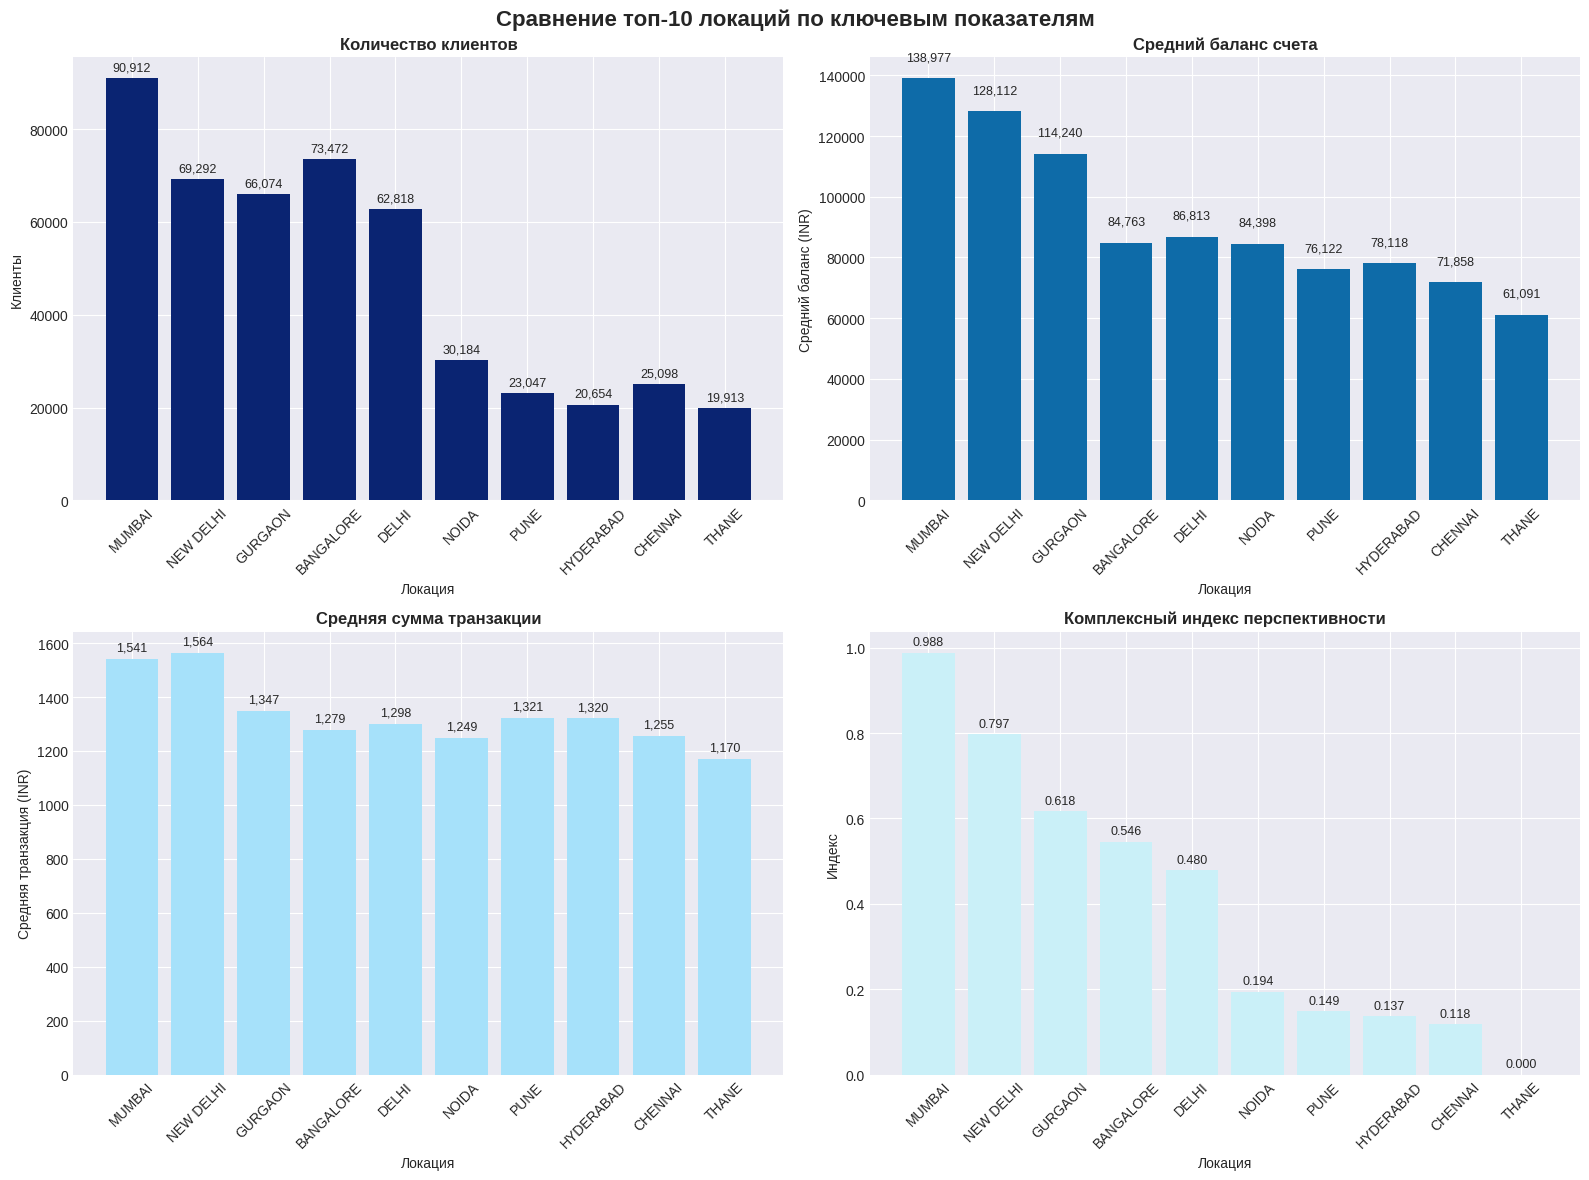


4. СЕГМЕНТАЦИЯ ЛОКАЦИЙ ПО ТИПАМ

Сегментация топ-10 локаций:
--------------------------------------------------------------------------------
Локация         Тип локации                                  
--------------------------------------------------------------------------------
MUMBAI          Высокодоходная / Крупные транзакции / Массовый рынок
BANGALORE       Среднедоходная / Низкие транзакции / Массовый рынок
NEW DELHI       Высокодоходная / Крупные транзакции / Средний рынок
GURGAON         Высокодоходная / Средние транзакции / Средний рынок
DELHI           Среднедоходная / Низкие транзакции / Средний рынок
NOIDA           Среднедоходная / Низкие транзакции / Средний рынок
CHENNAI         Низкодоходная / Низкие транзакции / Нишевый рынок
PUNE            Низкодоходная / Средние транзакции / Нишевый рынок
HYDERABAD       Низкодоходная / Средние транзакции / Нишевый рынок
THANE           Низкодоходная / Низкие транзакции / Нишевый рынок

5. ВЫВОДЫ И РЕКОМЕНДАЦИИ

НАИБОЛЕЕ ПЕРСП

In [30]:
# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 10)
sns.set_palette("viridis")

print("=" * 80)
print("АНАЛИЗ НАИБОЛЕЕ ПЕРСПЕКТИВНЫХ ЛОКАЦИЙ")
print("=" * 80)

camel_case = {
    'Клиенты,%': 'Клиенты_%',
    'Ср.баланс': 'Ср_баланс',
    'Ср.транзакция': 'Ср_транзакция',
    'Транзакции,%': 'Транзакции_%',

}

df_top10 = summary_df.rename(columns=camel_case)

# 1. МНОГОКРИТЕРИАЛЬНЫЙ АНАЛИЗ
print("\n" + "=" * 80)
print("1. МНОГОКРИТЕРИАЛЬНЫЙ АНАЛИЗ ТОП-10 ЛОКАЦИЙ")
print("=" * 80)

# Нормализуем показатели для сравнения (0-1)
for col in ['Клиенты', 'Ср_баланс', 'Ср_транзакция', 'Транзакции']:
    df_top10[f'{col}_норм'] = (df_top10[col] - df_top10[col].min()) / (df_top10[col].max() - df_top10[col].min())

# Создаем комплексный индекс (взвешенная сумма)
weights = {
    'Клиенты_норм': 0.30,        # Размер клиентской базы
    'Ср_баланс_норм': 0.25,      # Финансовое благосостояние
    'Ср_транзакция_норм': 0.20,  # Средняя транзакция
    'Транзакции_норм': 0.25      # Активность
}

df_top10['Комплексный_индекс'] = (
    df_top10['Клиенты_норм'] * weights['Клиенты_норм'] +
    df_top10['Ср_баланс_норм'] * weights['Ср_баланс_норм'] +
    df_top10['Ср_транзакция_норм'] * weights['Ср_транзакция_норм'] +
    df_top10['Транзакции_норм'] * weights['Транзакции_норм']
)

# Сортируем по комплексному индексу
df_top10_sorted = df_top10.sort_values('Комплексный_индекс', ascending=False)

print("\nРейтинг локаций по комплексному индексу:")
print("-" * 120)
print(f"{'Ранг':<6} {'Локация':<15} {'Индекс':<10} {'Клиенты':<12} {'Ср.баланс':<15} {'Ср.транзакция':<15} {'Транзакции':<12}")
print("-" * 120)

for i, (_, row) in enumerate(df_top10_sorted.iterrows(), 1):
    print(f"{i:<6} {row['Локация']:<15} {row['Комплексный_индекс']:<10.3f} "
          f"{row['Клиенты']:<12,} {row['Ср_баланс']:<15,.2f} "
          f"{row['Ср_транзакция']:<15,.2f} {row['Транзакции']:<12,}")

# 2. АНАЛИЗ ПО КОНКРЕТНЫМ КРИТЕРИЯМ
print("\n" + "=" * 80)
print("2. АНАЛИЗ ПО КЛЮЧЕВЫМ КРИТЕРИЯМ")
print("=" * 80)

# Критерий 1: Наибольшее количество клиентов
print("\nа) Локации с наибольшим количеством клиентов:")
top_clients = df_top10.nlargest(3, 'Клиенты')[['Локация', 'Клиенты', 'Клиенты_%']]
for i, (_, row) in enumerate(top_clients.iterrows(), 1):
    print(f"  {i}. {row['Локация']}: {row['Клиенты']:,} клиентов ({row['Клиенты_%']}%)")  # Исправлено здесь

# Критерий 2: Самые высокие средние балансы
print("\nб) Локации с самыми высокими средними балансами:")
top_balance = df_top10.nlargest(3, 'Ср_баланс')[['Локация', 'Ср_баланс']]
for i, (_, row) in enumerate(top_balance.iterrows(), 1):
    print(f"  {i}. {row['Локация']}: {row['Ср_баланс']:,.2f} INR")

# Критерий 3: Самые высокие средние транзакции
print("\nв) Локации с самыми высокими средними транзакциями:")
top_transaction = df_top10.nlargest(3, 'Ср_транзакция')[['Локация', 'Ср_транзакция']]
for i, (_, row) in enumerate(top_transaction.iterrows(), 1):
    print(f"  {i}. {row['Локация']}: {row['Ср_транзакция']:,.2f} INR")

# Критерий 4: Наибольшее количество транзакций
print("\nг) Локации с наибольшим количеством транзакций:")
top_transactions = df_top10.nlargest(3, 'Транзакции')[['Локация', 'Транзакции', 'Транзакции_%']]
for i, (_, row) in enumerate(top_transactions.iterrows(), 1):
    print(f"  {i}. {row['Локация']}: {row['Транзакции']:,} транзакций ({row['Транзакции_%']}%)")

# 3. АНАЛИЗ СООТНОШЕНИЯ ПОКАЗАТЕЛЕЙ
print("\n" + "=" * 80)
print("3. АНАЛИЗ ЭФФЕКТИВНОСТИ И ПЛАТЕЖЕСПОСОБНОСТИ")
print("=" * 80)

# Рассчитываем дополнительные метрики
df_top10['Баланс_на_клиента'] = df_top10['Ср_баланс']
df_top10['Транзакция_на_клиента'] = df_top10['Транзакции'] / df_top10['Клиенты']
df_top10['Проникновение_услуг'] = df_top10['Транзакции'] / df_top10['Клиенты']  # активность клиентов
df_top10['Эффективность'] = df_top10['Ср_транзакция'] * df_top10['Транзакция_на_клиента']

print("\nа) Соотношение среднего баланса и средней транзакции:")
print("-" * 70)
print(f"{'Локация':<15} {'Баланс/Транзакция':<20} {'Интерпретация':<35}")
print("-" * 70)

for _, row in df_top10.iterrows():
    ratio = row['Ср_баланс'] / row['Ср_транзакция'] if row['Ср_транзакция'] > 0 else 0
    if ratio > 100:
        interpretation = "Высокая платежеспособность"
    elif ratio > 50:
        interpretation = "Средняя платежеспособность"
    else:
        interpretation = "Низкая платежеспособность"
    print(f"{row['Локация']:<15} {ratio:<20.1f} {interpretation:<35}")

print("\nб) Активность клиентов (транзакций на клиента):")
print("-" * 50)
active_locations = df_top10.nlargest(3, 'Проникновение_услуг')[['Локация', 'Проникновение_услуг']]
for i, (_, row) in enumerate(active_locations.iterrows(), 1):
    print(f"  {i}. {row['Локация']}: {row['Проникновение_услуг']:.2f} транзакций/клиента")

# 4. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Сравнение топ-10 локаций по ключевым показателям', fontsize=16, fontweight='bold')

# График 1: Количество клиентов
ax1 = axes[0, 0]
bars1 = ax1.bar(df_top10_sorted['Локация'], df_top10_sorted['Клиенты'], color='#0a2472')
ax1.set_title('Количество клиентов', fontweight='bold')
ax1.set_xlabel('Локация')
ax1.set_ylabel('Клиенты')
ax1.tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# График 2: Средний баланс
ax2 = axes[0, 1]
bars2 = ax2.bar(df_top10_sorted['Локация'], df_top10_sorted['Ср_баланс'], color='#0e6ba8')
ax2.set_title('Средний баланс счета', fontweight='bold')
ax2.set_xlabel('Локация')
ax2.set_ylabel('Средний баланс (INR)')
ax2.tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5000,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# График 3: Средняя транзакция
ax3 = axes[1, 0]
bars3 = ax3.bar(df_top10_sorted['Локация'], df_top10_sorted['Ср_транзакция'], color='#a6e1fa')
ax3.set_title('Средняя сумма транзакции', fontweight='bold')
ax3.set_xlabel('Локация')
ax3.set_ylabel('Средняя транзакция (INR)')
ax3.tick_params(axis='x', rotation=45)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# График 4: Комплексный индекс
ax4 = axes[1, 1]
bars4 = ax4.bar(df_top10_sorted['Локация'], df_top10_sorted['Комплексный_индекс'], color='#caf0f8')
ax4.set_title('Комплексный индекс перспективности', fontweight='bold')
ax4.set_xlabel('Локация')
ax4.set_ylabel('Индекс')
ax4.tick_params(axis='x', rotation=45)
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 5. СЕГМЕНТАЦИЯ ЛОКАЦИЙ ПО ТИПАМ
print("\n" + "=" * 80)
print("4. СЕГМЕНТАЦИЯ ЛОКАЦИЙ ПО ТИПАМ")
print("=" * 80)

# Определяем тип локации на основе характеристик
location_types = []

for _, row in df_top10.iterrows():
    loc_type = []

    # Критерии определения типа
    if row['Ср_баланс'] > 100000:
        loc_type.append("Высокодоходная")
    elif row['Ср_баланс'] > 80000:
        loc_type.append("Среднедоходная")
    else:
        loc_type.append("Низкодоходная")

    if row['Ср_транзакция'] > 1500:
        loc_type.append("Крупные транзакции")
    elif row['Ср_транзакция'] > 1300:
        loc_type.append("Средние транзакции")
    else:
        loc_type.append("Низкие транзакции")

    if row['Клиенты'] > 70000:
        loc_type.append("Массовый рынок")
    elif row['Клиенты'] > 30000:
        loc_type.append("Средний рынок")
    else:
        loc_type.append("Нишевый рынок")

    location_types.append(" / ".join(loc_type))

df_top10['Тип_локации'] = location_types

print("\nСегментация топ-10 локаций:")
print("-" * 80)
print(f"{'Локация':<15} {'Тип локации':<45}")
print("-" * 80)

for _, row in df_top10.iterrows():
    print(f"{row['Локация']:<15} {row['Тип_локации']:<45}")

# 6. ВЫВОДЫ И РЕКОМЕНДАЦИИ
print("\n" + "=" * 80)
print("5. ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("=" * 80)

# Определяем наиболее перспективные локации по разным критериям
print("\nНАИБОЛЕЕ ПЕРСПЕКТИВНЫЕ ЛОКАЦИИ:")

# По комплексному индексу
print(f"\n1. По комплексному индексу:")
top1 = df_top10_sorted.iloc[0]
print(f"   🥇 {top1['Локация']} (индекс: {top1['Комплексный_индекс']:.3f})")
print(f"   • Крупнейшая клиентская база: {top1['Клиенты']:,} клиентов")
print(f"   • Высокий средний баланс: {top1['Ср_баланс']:,.2f} INR")
print(f"   • Максимальная активность: {top1['Транзакции']:,} транзакций")

# По платежеспособности
print(f"\n2. По платежеспособности клиентов:")
top_balance_loc = df_top10.nlargest(1, 'Ср_баланс').iloc[0]
print(f"   🥇 {top_balance_loc['Локация']} (средний баланс: {top_balance_loc['Ср_баланс']:,.2f} INR)")
print(f"   • Соотношение баланс/транзакция: {top_balance_loc['Ср_баланс']/top_balance_loc['Ср_транзакция']:.1f}")

# По активности
print(f"\n3. По активности клиентов:")
top_active = df_top10.nlargest(1, 'Транзакция_на_клиента').iloc[0]
print(f"   🥇 {top_active['Локация']} ({top_active['Транзакция_на_клиента']:.2f} транзакций/клиента)")


🏆 НАИБОЛЕЕ ПЕРСПЕКТИВНАЯ ЛОКАЦИЯ: MUMBAI
--------------------------------------------------
Основания:
1. Самый высокий средний баланс: 138,976.64 INR
2. Высокая средняя транзакция: 1,540.75 INR
3. Крупная клиентская база: 90,911 клиентов
4. Высокая активность: 92,394 транзакций
5. Лучший комплексный индекс: 0.988



In [ ]:
# посмотреть динамику транзакций по дате (в кол-ве TransactionID)

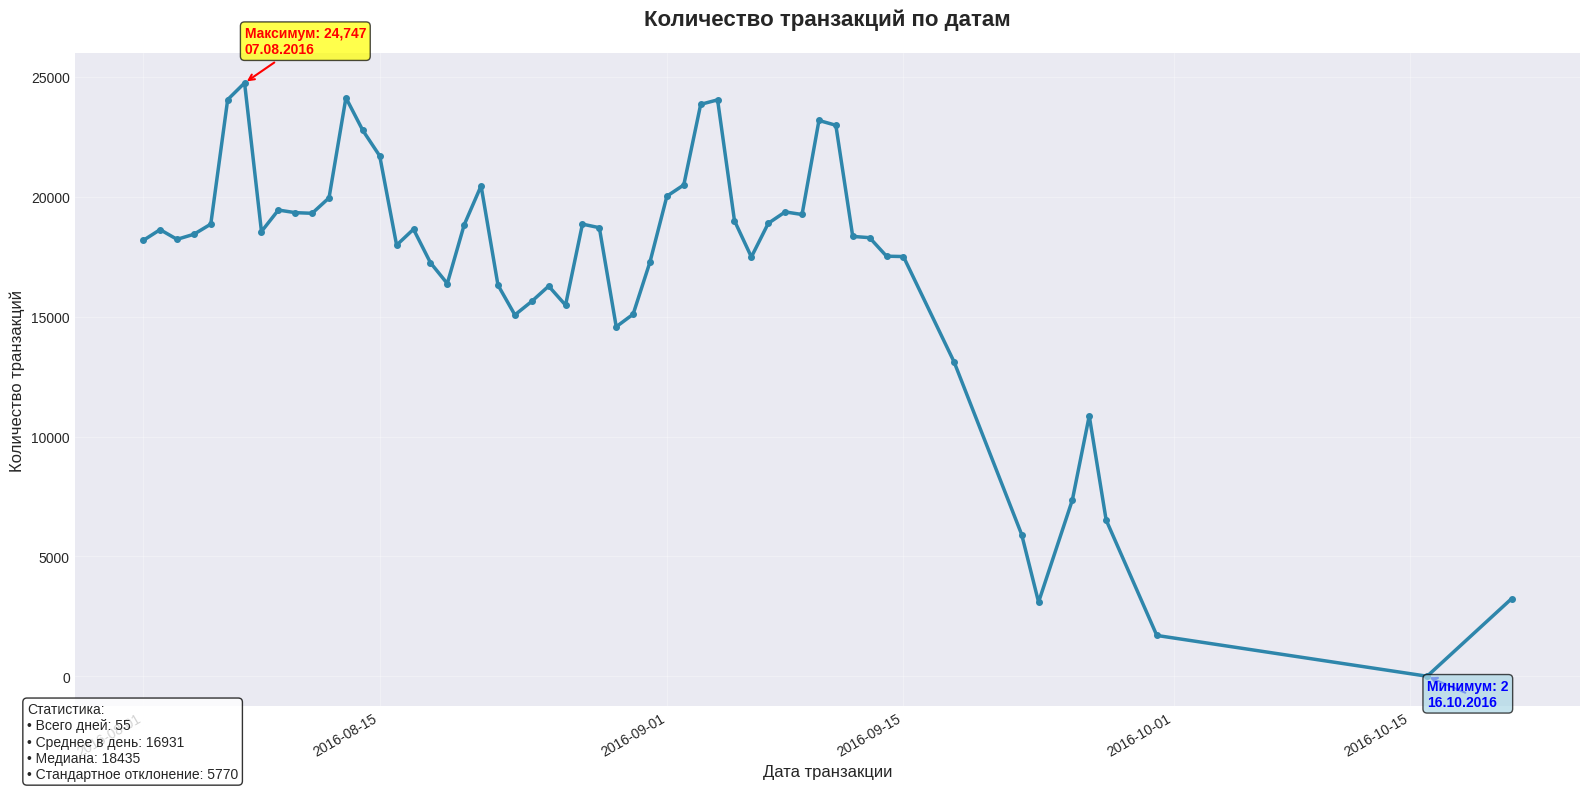

СТАТИСТИКА ТРАНЗАКЦИЙ ПО ДАТАМ
Всего транзакций: 931,212
Период данных: с 01.08.2016 по 21.10.2016
Всего дней с транзакциями: 55

Топ-5 дней по количеству транзакций:
--------------------------------------------------
07.08.2016: 24,747 транзакций
13.08.2016: 24,130 транзакций
06.08.2016: 24,051 транзакций
04.09.2016: 24,041 транзакций
03.09.2016: 23,855 транзакций

Минимальные 5 дней по количеству транзакций:
--------------------------------------------------
16.10.2016: 2 транзакций
30.09.2016: 1,703 транзакций
23.09.2016: 3,094 транзакций
21.10.2016: 3,236 транзакций
22.09.2016: 5,912 транзакций


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 6)
sns.set_palette("viridis")

# Подсчет количества транзакций по датам
transactions_by_date = df.groupby('transaction_date').size()

# Построение графика
plt.figure(figsize=(16, 8))

# Линейный график
plt.plot(transactions_by_date.index, transactions_by_date.values,
         linewidth=2.5, marker='o', markersize=4, color='#2E86AB')

# Настройки графика
plt.title('Количество транзакций по датам', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата транзакции', fontsize=12)
plt.ylabel('Количество транзакций', fontsize=12)
plt.grid(True, alpha=0.3)

# Форматирование оси X
plt.gcf().autofmt_xdate()

# Добавление аннотаций для пиковых значений
max_date = transactions_by_date.idxmax()
max_value = transactions_by_date.max()
min_date = transactions_by_date.idxmin()
min_value = transactions_by_date.min()

plt.annotate(f'Максимум: {max_value:,}\n{max_date.strftime("%d.%m.%Y")}',
             xy=(max_date, max_value), xytext=(max_date, max_value + max_value*0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.annotate(f'Минимум: {min_value:,}\n{min_date.strftime("%d.%m.%Y")}',
             xy=(min_date, min_value), xytext=(min_date, min_value - max_value*0.05),
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
             fontsize=10, fontweight='bold', color='blue',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

# Статистика
plt.figtext(0.02, 0.02,
            f'Статистика:\n'
            f'• Всего дней: {len(transactions_by_date):,}\n'
            f'• Среднее в день: {transactions_by_date.mean():.0f}\n'
            f'• Медиана: {transactions_by_date.median():.0f}\n'
            f'• Стандартное отклонение: {transactions_by_date.std():.0f}',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Дополнительная информация в консоли
print("=" * 60)
print("СТАТИСТИКА ТРАНЗАКЦИЙ ПО ДАТАМ")
print("=" * 60)
print(f"Всего транзакций: {len(df):,}")
print(f"Период данных: с {df['transaction_date'].min().strftime('%d.%m.%Y')} "
      f"по {df['transaction_date'].max().strftime('%d.%m.%Y')}")
print(f"Всего дней с транзакциями: {len(transactions_by_date):,}")
print(f"\nТоп-5 дней по количеству транзакций:")
print("-" * 50)
top_days = transactions_by_date.nlargest(5)
for date, count in top_days.items():
    print(f"{date.strftime('%d.%m.%Y')}: {count:,} транзакций")

print(f"\nМинимальные 5 дней по количеству транзакций:")
print("-" * 50)
bottom_days = transactions_by_date.nsmallest(5)
for date, count in bottom_days.items():
    print(f"{date.strftime('%d.%m.%Y')}: {count:,} транзакций")

In [ ]:
# посмотреть динамику транзакций по дате (в сумме TransactionAmount)

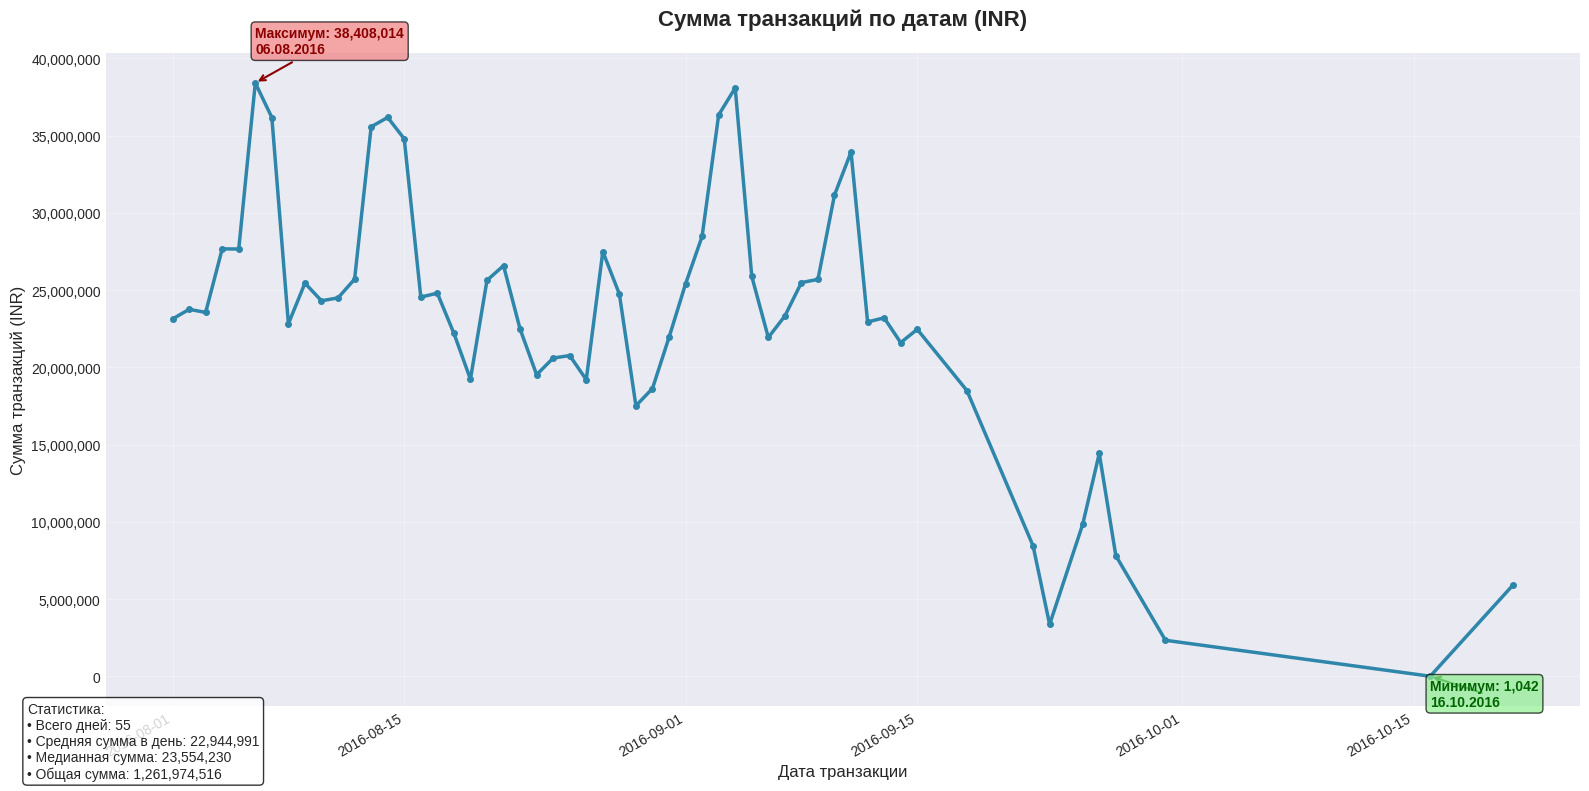

СТАТИСТИКА СУММ ТРАНЗАКЦИЙ ПО ДАТАМ
Общая сумма всех транзакций: 1,261,974,516.26
Период данных: с 01.08.2016 по 21.10.2016
Всего дней с транзакциями: 55

Топ-5 дней по сумме транзакций:
------------------------------------------------------------
06.08.2016: 38,408,013.98
04.09.2016: 38,084,044.18
03.09.2016: 36,336,523.61
14.08.2016: 36,176,003.20
07.08.2016: 36,169,683.20

Минимальные 5 дней по сумме транзакций:
------------------------------------------------------------
16.10.2016: 1,042.00
30.09.2016: 2,328,769.71
23.09.2016: 3,356,575.45
21.10.2016: 5,903,611.48
27.09.2016: 7,807,119.90


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 6)
sns.set_palette("viridis")

# Расчет суммы транзакций по датам
transactions_sum_by_date = df.groupby('transaction_date')['transaction_amount_inr'].sum()

# Построение графика
plt.figure(figsize=(16, 8))

# Линейный график
plt.plot(transactions_sum_by_date.index, transactions_sum_by_date.values,
         linewidth=2.5, marker='o', markersize=4, color='#2E86AB')

# Настройки графика
plt.title('Сумма транзакций по датам (INR)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата транзакции', fontsize=12)
plt.ylabel('Сумма транзакций (INR)', fontsize=12)
plt.grid(True, alpha=0.3)

# Форматирование оси X
plt.gcf().autofmt_xdate()

# Форматирование оси Y для отображения больших чисел
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Добавление аннотаций для пиковых значений
max_date = transactions_sum_by_date.idxmax()
max_value = transactions_sum_by_date.max()
min_date = transactions_sum_by_date.idxmin()
min_value = transactions_sum_by_date.min()

plt.annotate(f'Максимум: {max_value:,.0f}\n{max_date.strftime("%d.%m.%Y")}',
             xy=(max_date, max_value), xytext=(max_date, max_value + max_value*0.05),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))

plt.annotate(f'Минимум: {min_value:,.0f}\n{min_date.strftime("%d.%m.%Y")}',
             xy=(min_date, min_value), xytext=(min_date, min_value - max_value*0.05),
             arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
             fontsize=10, fontweight='bold', color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Статистика
plt.figtext(0.02, 0.02,
            f'Статистика:\n'
            f'• Всего дней: {len(transactions_sum_by_date):,}\n'
            f'• Средняя сумма в день: {transactions_sum_by_date.mean():,.0f}\n'
            f'• Медианная сумма: {transactions_sum_by_date.median():,.0f}\n'
            f'• Общая сумма: {transactions_sum_by_date.sum():,.0f}',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Дополнительная информация в консоли
print("=" * 60)
print("СТАТИСТИКА СУММ ТРАНЗАКЦИЙ ПО ДАТАМ")
print("=" * 60)
print(f"Общая сумма всех транзакций: {df['transaction_amount_inr'].sum():,.2f}")
print(f"Период данных: с {df['transaction_date'].min().strftime('%d.%m.%Y')} "
      f"по {df['transaction_date'].max().strftime('%d.%m.%Y')}")
print(f"Всего дней с транзакциями: {len(transactions_sum_by_date):,}")
print(f"\nТоп-5 дней по сумме транзакций:")
print("-" * 60)
top_days = transactions_sum_by_date.nlargest(5)
for date, amount in top_days.items():
    print(f"{date.strftime('%d.%m.%Y')}: {amount:,.2f}")

print(f"\nМинимальные 5 дней по сумме транзакций:")
print("-" * 60)
bottom_days = transactions_sum_by_date.nsmallest(5)
for date, amount in bottom_days.items():
    print(f"{date.strftime('%d.%m.%Y')}: {amount:,.2f}")

In [ ]:
# разбить клиентов на корзины по возрасту и определить самую платежеспособную группу

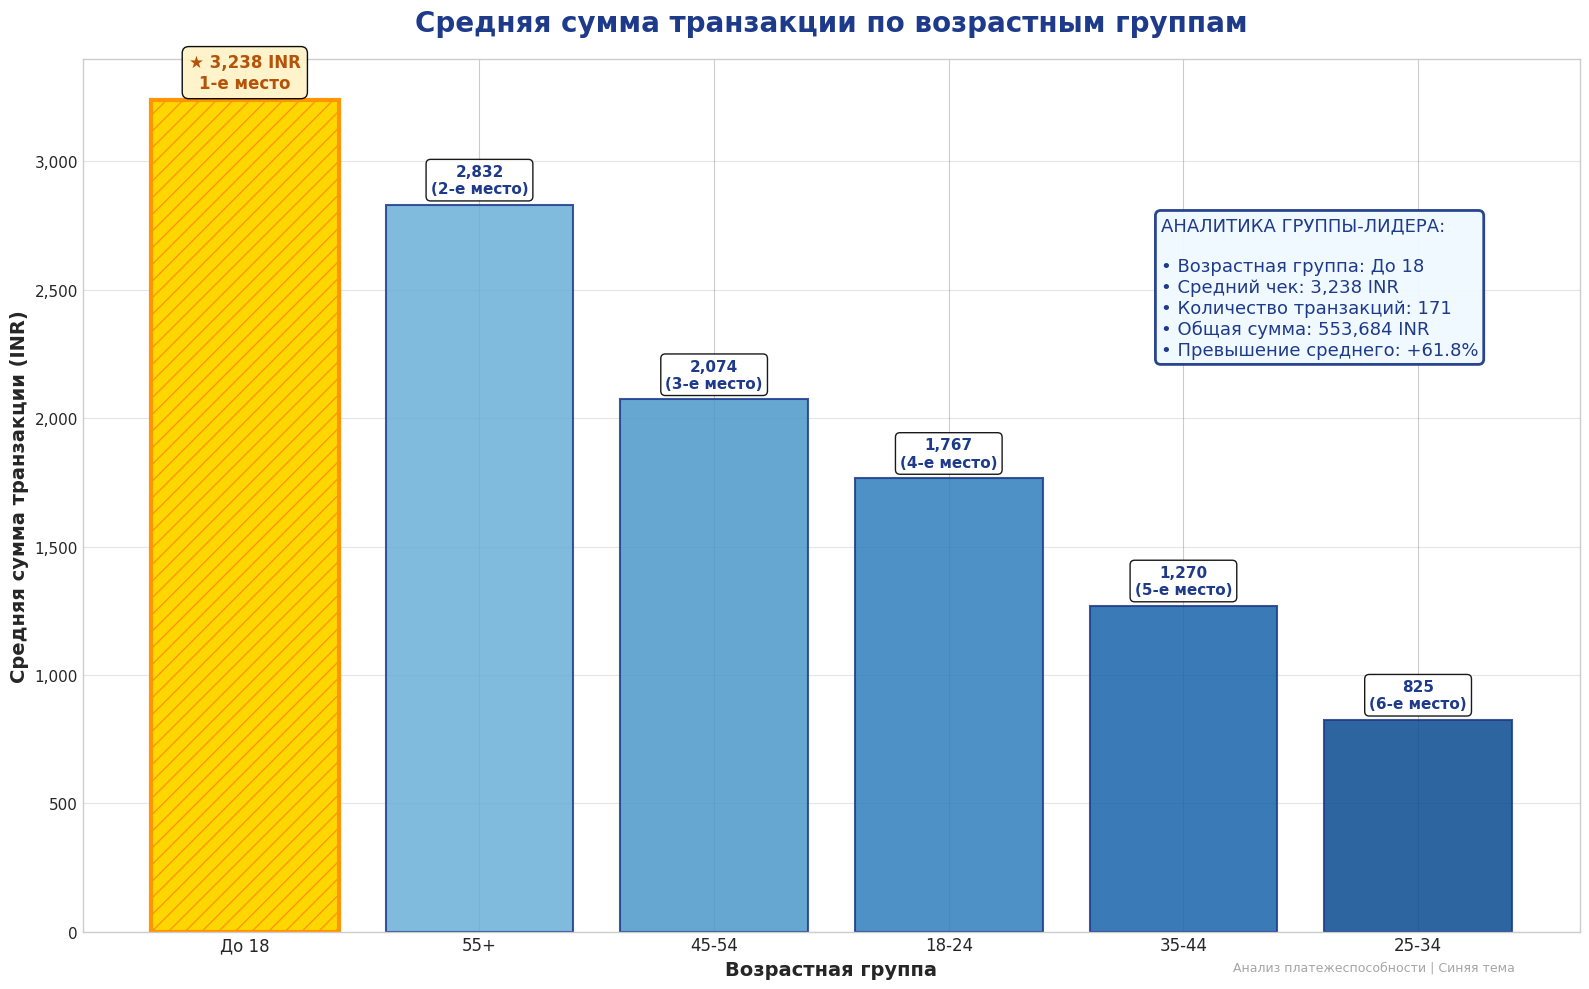

АНАЛИЗ ПЛАТЕЖЕСПОСОБНОСТИ ПО ВОЗРАСТНЫМ ГРУППАМ
Всего транзакций: 931,212
Всего возрастных групп: 6

Рейтинг возрастных групп по средней сумме транзакции:
----------------------------------------------------------------------
Место  Возрастная группа Средний чек (INR)    Транзакций   Общая сумма         
----------------------------------------------------------------------
1      🏆До 18                       3,238          171            553,684
2      55+                         2,832       20,603         58,338,167
3      45-54                       2,074      168,273        348,926,007
4      18-24                       1,767          355            627,240
5      35-44                       1,270      542,631        689,174,992
6      25-34                         825      199,179        164,354,427


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import matplotlib.patches as mpatches
import warnings

# Отключаем предупреждения о символах
warnings.filterwarnings('ignore', category=UserWarning)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['figure.figsize'] = (14, 8)
# Устанавливаем шрифт, который поддерживает больше символов
rcParams['font.family'] = 'DejaVu Sans'  # Или 'Arial', 'sans-serif'

# Синяя цветовая палитра
BLUE_PALETTE = ['#03045e', '#0077b6', '#00b4d8', '#90e0ef', '#caf0f8', '#ade8f4']
GOLD_COLOR = '#ffd700'  # Для выделения лидера
DARK_BLUE = '#1e3a8a'
LIGHT_BLUE = '#93c5fd'

# Создаем возрастные группы (корзины)
age_bins = [0, 18, 25, 35, 45, 55, 120]
age_labels = ['До 18', '18-24', '25-34', '35-44', '45-54', '55+']

# Добавляем возрастные группы в DataFrame
df['age_group'] = pd.cut(df['age_int'], bins=age_bins, labels=age_labels, right=False)

# Рассчитываем метрики
avg_transaction_by_age = df.groupby('age_group', observed=False)['transaction_amount_inr'].mean().sort_values(ascending=False)
total_transaction_by_age = df.groupby('age_group', observed=False)['transaction_amount_inr'].sum()
count_transaction_by_age = df.groupby('age_group', observed=False)['transaction_amount_inr'].count()

# Создание градиента синих цветов
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(avg_transaction_by_age)))

# Построение графика
fig, ax = plt.subplots(figsize=(16, 10))

# Основной график - средняя транзакция по возрастным группам
bars = ax.bar(avg_transaction_by_age.index, avg_transaction_by_age.values,
               color=colors,
               edgecolor=DARK_BLUE, linewidth=1.5, alpha=0.85)

# Настройки графика
ax.set_title('Средняя сумма транзакции по возрастным группам',
             fontsize=20, fontweight='bold', pad=20, color=DARK_BLUE)
ax.set_xlabel('Возрастная группа', fontsize=14, fontweight='semibold')
ax.set_ylabel('Средняя сумма транзакции (INR)', fontsize=14, fontweight='semibold')
ax.grid(True, axis='y', alpha=0.3, linestyle='--', color='gray')

# Форматирование оси Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Находим лидирующую группу
most_paying_group = avg_transaction_by_age.idxmax()
most_paying_value = avg_transaction_by_age.max()
max_value = avg_transaction_by_age.max()

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars, avg_transaction_by_age.values)):
    # Подсветка самой платежеспособной группы
    if avg_transaction_by_age.index[i] == most_paying_group:
        bar.set_color(GOLD_COLOR)
        bar.set_edgecolor('#ff9500')
        bar.set_linewidth(3)
        bar.set_alpha(1)
        bar.set_hatch('//')

    # Добавляем аннотации
    position = bar.get_x() + bar.get_width()/2
    height = bar.get_height()

    # Для лидера - особое оформление
    if avg_transaction_by_age.index[i] == most_paying_group:
        ax.text(position, height + max_value*0.01,
                 f'★ {value:,.0f} INR\n1-е место',  # Изменено с эмодзи на звезду
                 ha='center', va='bottom', fontsize=12, fontweight='bold',
                 color='#b45309',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='#fef3c7', alpha=0.95))
    else:
        ax.text(position, height + max_value*0.01,
                 f'{value:,.0f}\n({i+1}-е место)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 color=DARK_BLUE,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Статистика в стилизованной панели (без эмодзи)
stats_text = (f'АНАЛИТИКА ГРУППЫ-ЛИДЕРА:\n\n'
              f'• Возрастная группа: {most_paying_group}\n'
              f'• Средний чек: {most_paying_value:,.0f} INR\n'
              f'• Количество транзакций: {count_transaction_by_age[most_paying_group]:,}\n'
              f'• Общая сумма: {total_transaction_by_age[most_paying_group]:,.0f} INR\n'
              f'• Превышение среднего: +{((most_paying_value/avg_transaction_by_age.mean())-1)*100:.1f}%')

# Создаем панель для статистики
props = dict(boxstyle='round', facecolor='#f0f9ff', alpha=0.95,
             edgecolor=DARK_BLUE, linewidth=2)
ax.text(0.72, 0.82, stats_text, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props, color=DARK_BLUE)



# Настраиваем внешний вид
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

# Добавляем фоновую сетку для лучшей читаемости
ax.set_axisbelow(True)
ax.grid(True, axis='y', alpha=0.2, linestyle='-', color='gray')

plt.tight_layout()

# Добавляем подпись без эмодзи
fig.text(0.95, 0.02, 'Анализ платежеспособности | Синяя тема',
         fontsize=9, color='gray', alpha=0.7,
         ha='right', va='bottom', rotation=0)

plt.show()



# Дополнительная информация в консоли
print("=" * 70)
print("АНАЛИЗ ПЛАТЕЖЕСПОСОБНОСТИ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 70)
print(f"Всего транзакций: {len(df):,}")
print(f"Всего возрастных групп: {len(age_labels)}")
print(f"\nРейтинг возрастных групп по средней сумме транзакции:")
print("-" * 70)
print(f"{'Место':<6} {'Возрастная группа':<15} {'Средний чек (INR)':<20} {'Транзакций':<12} {'Общая сумма':<20}")
print("-" * 70)

for i, (group, value) in enumerate(avg_transaction_by_age.items(), 1):
    count = count_transaction_by_age[group]
    total = total_transaction_by_age[group]

    if group == most_paying_group:
        marker = "🏆"
    else:
        marker = ""

    print(f"{i:<6} {marker}{group:<14} {value:>18,.0f} {count:>12,} {total:>18,.0f}")

🔍 Ключевые наблюдения\
Самый высокий средний чек — у клиентов младше 18 лет: 3 238 INR\
Однако объём крайне мал: всего 171 транзакция на сумму 554 тыс. INR.\
→ Это может быть связано с:\
редкими, но крупными покупками (например, подарки, техника),
ошибками в указании возраста,\
специфическим поведением (покупки через родительские карты).\
Второе место — возрастная группа 55+\
Средний чек: 2 832 INR\
При этом высокая активность: 20 603 транзакции, общая сумма — 58,3 млн INR.\
→ Это наиболее ценностная и стабильная группа среди взрослых: высокий чек + значительный объём.\
Группы 45–54 и 18–24 также демонстрируют выше среднего чек
45–54: 2 074 INR при огромном объёме (168 тыс. транзакций) → ключевой драйвер выручки.\
18–24: 1 767 INR, но всего 355 транзакций → потенциально молодые пользователи с высокой платёжеспособностью, но низкой лояльностью.\
Самые массовые группы — 25–34 и 35–44\
Вместе они составляют ~740 тыс. транзакций (более 70% от общего числа).\
Однако их средний чек самый низкий (825–1 270 INR).\
→ Это основная аудитория по количеству, но не по ценности одной транзакции.\
💡 Рекомендации\
Фокус на группе 55+:\
Разрабатывать персонализированные предложения, программы лояльности — эта группа сочетает высокий чек и активность.\
Изучить группу «До 18»:\
Рассмотреть возможность таргетинга на родителей подростков.\
Повышать средний чек у массовых групп (25–44):\
Внедрить кросс-селлинг, рекомендательные системы, премиальные категории.\
Удержание молодёжи (18–24):\
Несмотря на высокий чек, низкая частота покупок говорит о риске оттока. Требуются программы вовлечения.\
📊 Итог\
Высокий средний чек ≠ высокая выручка.\
Группа 55+ — наиболее сбалансированная и ценная.\
Группы 25–44 — основа объёма, но требуют стратегий повышения ценности.\
Группа «До 18» — аномалия, требующая особого внимания.



In [ ]:
# посмотреть распредление транзакций по локации – вывести топ 10 по кол-ву транзакций/сумме транзакций

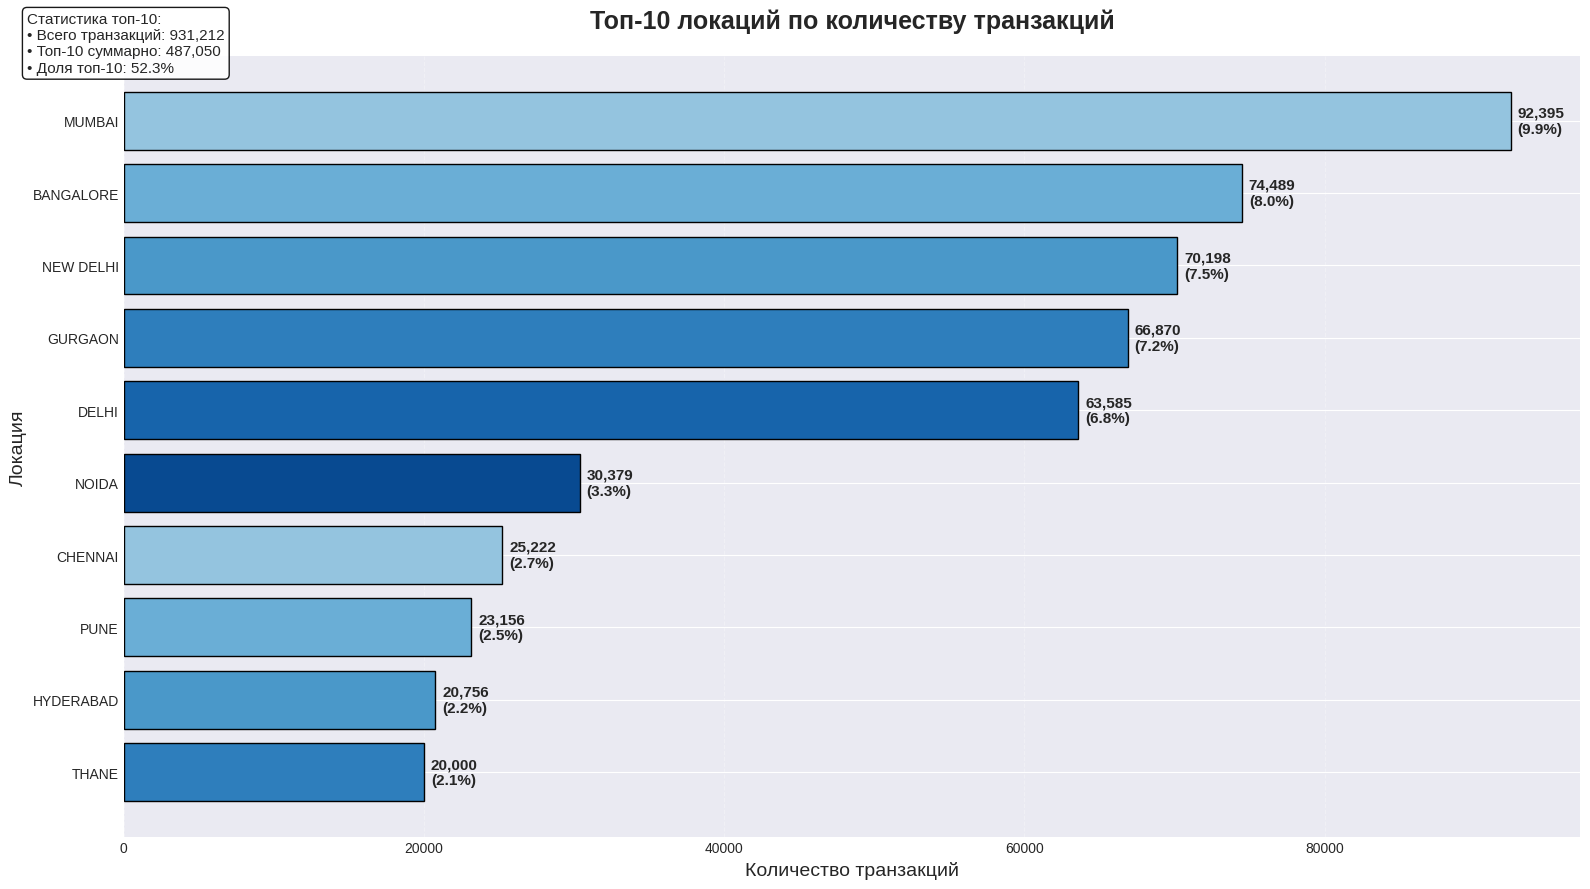

ТОП-10 ЛОКАЦИЙ ПО КОЛИЧЕСТВУ ТРАНЗАКЦИЙ
Всего транзакций: 931,212
Всего уникальных локаций: 7,823

Топ-10 локаций:
----------------------------------------------------------------------
№   Локация                                  Транзакции   Доля,%   Накопленная доля,%  
----------------------------------------------------------------------
1   MUMBAI                                   92,395          9.92%                9.92%
2   BANGALORE                                74,489          8.00%               17.92%
3   NEW DELHI                                70,198          7.54%               25.46%
4   GURGAON                                  66,870          7.18%               32.64%
5   DELHI                                    63,585          6.83%               39.47%
6   NOIDA                                    30,379          3.26%               42.73%
7   CHENNAI                                  25,222          2.71%               45.44%
8   PUNE                               

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 8)

# Подсчет количества транзакций по локациям
transactions_by_location = df['cust_location'].value_counts()

# Берем топ-10 локаций
top_10_locations = transactions_by_location.head(10)

# Создаем цветовую палитру
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(avg_transaction_by_age)))

# Построение графика
plt.figure(figsize=(16, 9))

# Горизонтальный bar chart
bars = plt.barh(range(len(top_10_locations)), top_10_locations.values, color=colors, edgecolor='black')

# Настройки графика
plt.title('Топ-10 локаций по количеству транзакций', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Количество транзакций', fontsize=14)
plt.ylabel('Локация', fontsize=14)
plt.yticks(range(len(top_10_locations)), [loc[:40] + '...' if len(loc) > 40 else loc for loc in top_10_locations.index])
plt.gca().invert_yaxis()  # Инвертируем ось Y для лучшего отображения

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars, top_10_locations.values)):
    # Процент от общего количества транзакций
    percent = (value / len(df)) * 100
    plt.text(value + max(top_10_locations.values)*0.005, bar.get_y() + bar.get_height()/2,
             f'{value:,}\n({percent:.1f}%)',
             va='center', fontsize=11, fontweight='bold')

# Добавляем сетку
plt.grid(True, axis='x', alpha=0.3, linestyle='--')

# Статистика в углу графика
total_transactions = len(df)
top_10_total = top_10_locations.sum()
top_10_percent = (top_10_total / total_transactions) * 100

plt.figtext(0.02, 0.98,
            f'Статистика топ-10:\n'
            f'• Всего транзакций: {total_transactions:,}\n'
            f'• Топ-10 суммарно: {top_10_total:,}\n'
            f'• Доля топ-10: {top_10_percent:.1f}%',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            verticalalignment='top')

plt.tight_layout()
plt.show()

# Дополнительная информация в консоли
print("=" * 70)
print("ТОП-10 ЛОКАЦИЙ ПО КОЛИЧЕСТВУ ТРАНЗАКЦИЙ")
print("=" * 70)
print(f"Всего транзакций: {len(df):,}")
print(f"Всего уникальных локаций: {df['cust_location'].nunique():,}")
print(f"\nТоп-10 локаций:")
print("-" * 70)
print(f"{'№':<3} {'Локация':<40} {'Транзакции':<12} {'Доля,%':<8} {'Накопленная доля,%':<20}")
print("-" * 70)

cumulative_percent = 0
for i, (location, count) in enumerate(top_10_locations.items(), 1):
    percent = (count / total_transactions) * 100
    cumulative_percent += percent
    # Обрезаем длинные названия локаций
    display_location = location[:38] + '...' if len(location) > 40 else location
    print(f"{i:<3} {display_location:<40} {count:<12,} {percent:>7.2f}% {cumulative_percent:>19.2f}%")

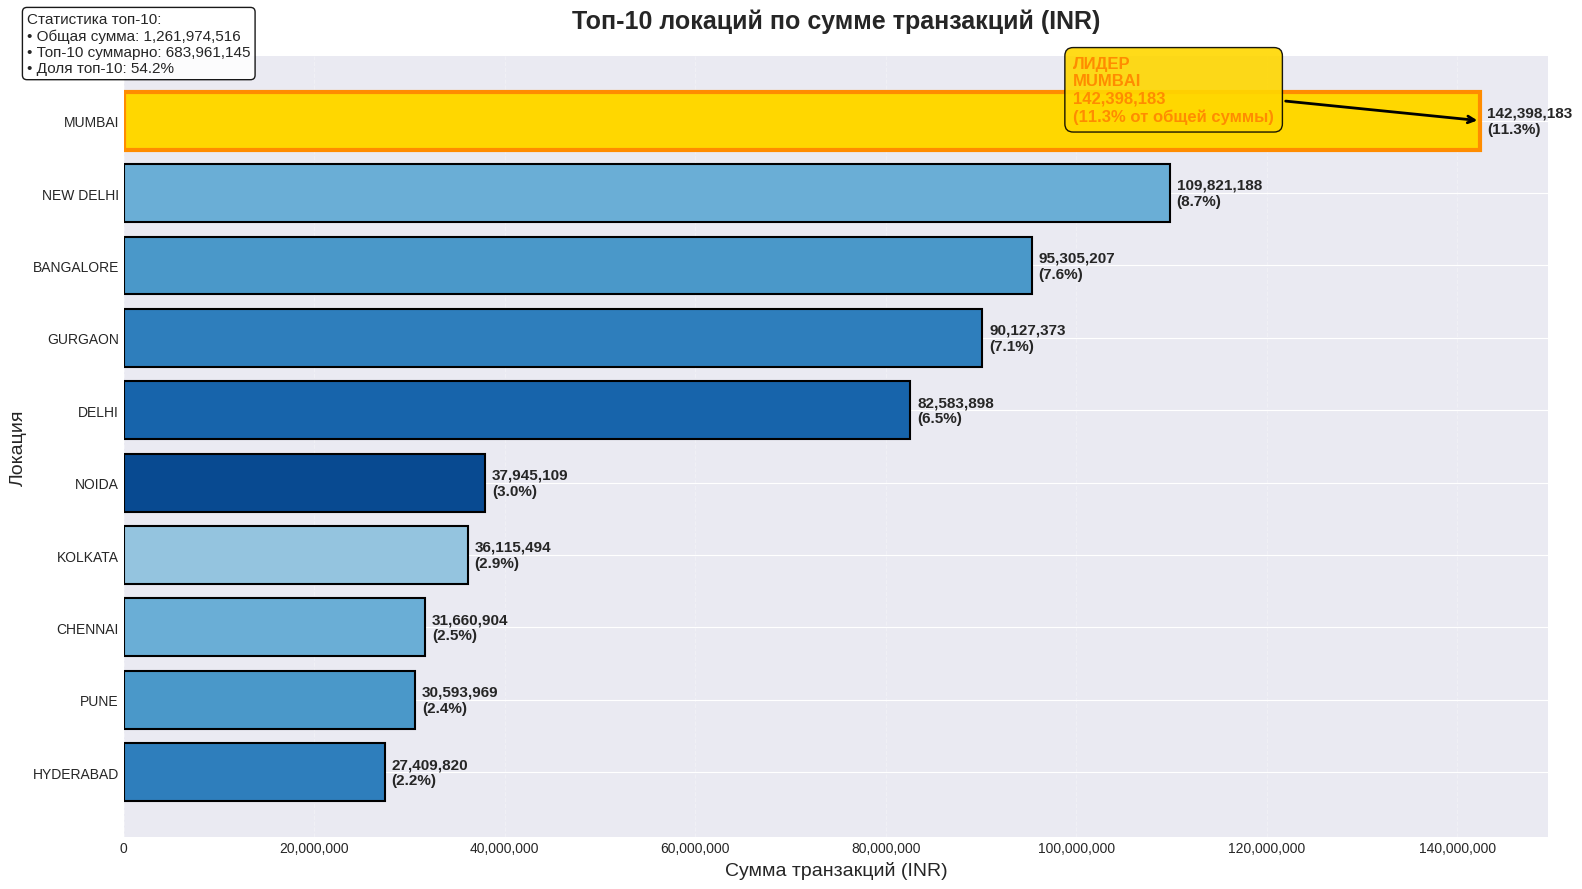

ТОП-10 ЛОКАЦИЙ ПО СУММЕ ТРАНЗАКЦИЙ
Общая сумма всех транзакций: 1,261,974,516.26
Всего уникальных локаций: 7,823

Топ-10 локаций по сумме транзакций:
----------------------------------------------------------------------
№   Локация                                  Сумма (INR)          Доля,%     Накопленная доля,%  
----------------------------------------------------------------------
1   🥇MUMBAI                                         142,398,183     11.28%               11.28%
2   🥈NEW DELHI                                      109,821,188      8.70%               19.99%
3   🥉BANGALORE                                       95,305,207      7.55%               27.54%
4   GURGAON                                         90,127,373      7.14%               34.68%
5   DELHI                                           82,583,898      6.54%               41.22%
6   NOIDA                                           37,945,109      3.01%               44.23%
7   KOLKATA                          

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 8)

# Подсчет суммы транзакций по локациям
transactions_sum_by_location = df.groupby('cust_location')['transaction_amount_inr'].sum()

# Сортируем по убыванию и берем топ-10
top_10_locations = transactions_sum_by_location.sort_values(ascending=False).head(10)

# Построение графика
plt.figure(figsize=(16, 9))


# Создаем цветовую палитру
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(avg_transaction_by_age)))


# Горизонтальный bar chart
bars = plt.barh(range(len(top_10_locations)), top_10_locations.values,
                color= colors,
                edgecolor='black', linewidth=1.5)

# Настройки графика
plt.title('Топ-10 локаций по сумме транзакций (INR)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Сумма транзакций (INR)', fontsize=14)
plt.ylabel('Локация', fontsize=14)
plt.yticks(range(len(top_10_locations)), [loc[:40] + '...' if len(loc) > 40 else loc for loc in top_10_locations.index])
plt.gca().invert_yaxis()  # Инвертируем ось Y для лучшего отображения

# Форматирование оси X для больших чисел
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars, top_10_locations.values)):
    # Процент от общей суммы транзакций
    percent = (value / df['transaction_amount_inr'].sum()) * 100
    plt.text(value + max(top_10_locations.values)*0.005, bar.get_y() + bar.get_height()/2,
             f'{value:,.0f}\n({percent:.1f}%)',
             va='center', fontsize=11, fontweight='bold')

# Добавляем сетку
plt.grid(True, axis='x', alpha=0.3, linestyle='--')

# Статистика в углу графика
total_sum = df['transaction_amount_inr'].sum()
top_10_sum = top_10_locations.sum()
top_10_percent = (top_10_sum / total_sum) * 100

plt.figtext(0.02, 0.98,
            f'Статистика топ-10:\n'
            f'• Общая сумма: {total_sum:,.0f}\n'
            f'• Топ-10 суммарно: {top_10_sum:,.0f}\n'
            f'• Доля топ-10: {top_10_percent:.1f}%',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            verticalalignment='top')

# Подсветка самой большой суммы
max_value = top_10_locations.max()
max_location = top_10_locations.idxmax()
max_bar_index = list(top_10_locations.index).index(max_location)
bars[max_bar_index].set_color('gold')
bars[max_bar_index].set_edgecolor('darkorange')
bars[max_bar_index].set_linewidth(3)

# Аннотация для локации с максимальной суммой
plt.annotate(f'ЛИДЕР\n{max_location[:30] + "..." if len(max_location) > 30 else max_location}\n'
             f'{max_value:,.0f}\n({(max_value/total_sum)*100:.1f}% от общей суммы)',
             xy=(max_value, max_bar_index),
             xytext=(max_value * 0.7, max_bar_index),
             arrowprops=dict(arrowstyle='->', color='black', lw=2),
             fontsize=12, fontweight='bold', color='darkorange',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', alpha=0.9))

plt.tight_layout()
plt.show()

# Дополнительная информация в консоли
print("=" * 70)
print("ТОП-10 ЛОКАЦИЙ ПО СУММЕ ТРАНЗАКЦИЙ")
print("=" * 70)
print(f"Общая сумма всех транзакций: {df['transaction_amount_inr'].sum():,.2f}")
print(f"Всего уникальных локаций: {df['cust_location'].nunique():,}")
print(f"\nТоп-10 локаций по сумме транзакций:")
print("-" * 70)
print(f"{'№':<3} {'Локация':<40} {'Сумма (INR)':<20} {'Доля,%':<10} {'Накопленная доля,%':<20}")
print("-" * 70)

cumulative_percent = 0
for i, (location, amount) in enumerate(top_10_locations.items(), 1):
    percent = (amount / total_sum) * 100
    cumulative_percent += percent
    # Обрезаем длинные названия локаций
    display_location = location[:38] + '...' if len(location) > 40 else location

    if location == max_location:
        marker = "🥇"
    elif i == 2:
        marker = "🥈"
    elif i == 3:
        marker = "🥉"
    else:
        marker = ""

    print(f"{i:<3} {marker}{display_location:<39} {amount:>18,.0f} {percent:>9.2f}% {cumulative_percent:>19.2f}%")

In [ ]:
print(f"Количество строк в DataFrame: {len(df):,}")
print(f"Количество уникальных пользователей: {df['customer_id'].nunique():,}")

Количество строк в DataFrame: 931,212
Количество уникальных пользователей: 799,649


In [ ]:
# посмотреть распределение времени транзакции (TransactionTime). Перевести из миллисекунд в минуты

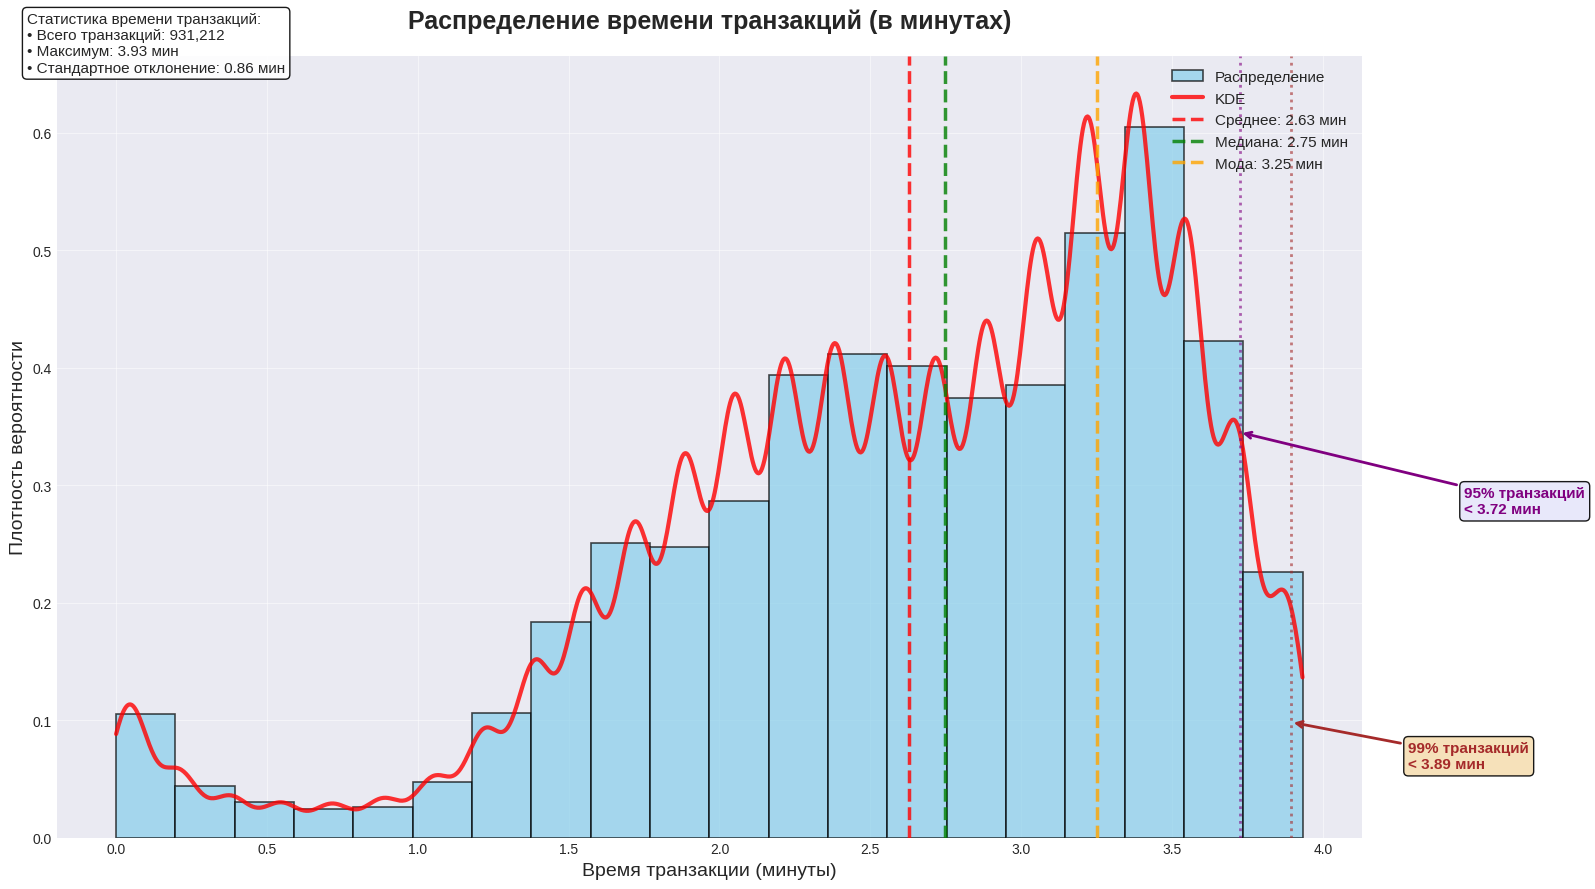

РАСПРЕДЕЛЕНИЕ ВРЕМЕНИ ТРАНЗАКЦИЙ (В МИНУТАХ)
Всего транзакций: 931,212

Базовая статистика:
--------------------------------------------------
Минимальное время: 0.0000 минут (0.0 секунд)
Максимальное время: 3.93 минут (236 секунд)
Среднее время: 2.63 минут (158 секунд)
Медианное время: 2.75 минут (165 секунд)
Стандартное отклонение: 0.86 минут

Процентили времени транзакций:
--------------------------------------------------
 25.0% транзакций:    2.07 мин (  124.3 сек)
 50.0% транзакций:    2.75 мин (  164.9 сек)
 75.0% транзакций:    3.34 мин (  200.3 сек)
 90.0% транзакций:    3.58 мин (  214.5 сек)
 95.0% транзакций:    3.72 мин (  223.5 сек)
 99.0% транзакций:    3.89 мин (  233.6 сек)
 99.9% транзакций:    3.93 мин (  235.7 сек)

Количество транзакций по временным категориям:
--------------------------------------------------
Менее 1 минуты         42,086 транзакций (  4.52%)
1-2 минут             152,863 транзакций ( 16.42%)
2-3 минут             341,925 транзакций ( 36.72%)
3+ 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 8)

# Конвертация миллисекунд в минуты
df['transaction_minutes'] = df['transaction_time'] / (1000 * 60)  # 1000 мс = 1 сек, 60 сек = 1 мин

# Построение гистограммы распределения времени транзакций
plt.figure(figsize=(16, 9))

# Гистограмма с KDE
n, bins, patches = plt.hist(df['transaction_minutes'], bins=20, alpha=0.7,
                           color='skyblue', edgecolor='black', linewidth=1.2,
                           density=True, label='Распределение')

# Добавляем KDE (Kernel Density Estimation)
from scipy import stats
kde = stats.gaussian_kde(df['transaction_minutes'])
x = np.linspace(df['transaction_minutes'].min(), df['transaction_minutes'].max(), 1000)
plt.plot(x, kde(x), 'r-', linewidth=3, label='KDE', alpha=0.8)

# Настройки графика
plt.title('Распределение времени транзакций (в минутах)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Время транзакции (минуты)', fontsize=14)
plt.ylabel('Плотность вероятности', fontsize=14)


# Вертикальные линии для ключевых статистик
mean_time = df['transaction_minutes'].mean()
median_time = df['transaction_minutes'].median()
mode_time = df['transaction_minutes'].mode()[0] if len(df['transaction_minutes'].mode()) > 0 else 0

plt.axvline(mean_time, color='red', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Среднее: {mean_time:.2f} мин')
plt.axvline(median_time, color='green', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Медиана: {median_time:.2f} мин')
plt.axvline(mode_time, color='orange', linestyle='--', linewidth=2.5, alpha=0.8, label=f'Мода: {mode_time:.2f} мин')

# Аннотация для 95-го перцентиля (быстрые транзакции)
percentile_95 = df['transaction_minutes'].quantile(0.95)
plt.axvline(percentile_95, color='purple', linestyle=':', linewidth=2, alpha=0.6)
plt.annotate(f'95% транзакций\n< {percentile_95:.2f} мин',
             xy=(percentile_95, kde(percentile_95)),
             xytext=(percentile_95*1.2, kde(percentile_95)*0.8),
             arrowprops=dict(arrowstyle='->', color='purple', lw=2),
             fontsize=11, fontweight='bold', color='purple',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lavender', alpha=0.9))

# Аннотация для 99-го перцентиля (очень долгие транзакции)
percentile_99 = df['transaction_minutes'].quantile(0.99)
plt.axvline(percentile_99, color='brown', linestyle=':', linewidth=2, alpha=0.6)
plt.annotate(f'99% транзакций\n< {percentile_99:.2f} мин',
             xy=(percentile_99, kde(percentile_99)*0.5),
             xytext=(percentile_99*1.1, kde(percentile_99)*0.3),
             arrowprops=dict(arrowstyle='->', color='brown', lw=2),
             fontsize=11, fontweight='bold', color='brown',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.9))

# Легенда
plt.legend(fontsize=11, loc='upper right')

# Статистика в углу графика
plt.figtext(0.02, 0.98,
            f'Статистика времени транзакций:\n'
            f'• Всего транзакций: {len(df):,}\n'
            f'• Максимум: {df["transaction_minutes"].max():.2f} мин\n'
            f'• Стандартное отклонение: {df["transaction_minutes"].std():.2f} мин',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            verticalalignment='top')

# шкала по оси X для лучшего отображения

plt.xlabel('Время транзакции (минуты)', fontsize=14)

# Добавляем вторую ось X с линейной шкалой для ключевых значений
# ax2 = plt.gca().twiny()
# key_values = [1, 2, 3, 4, 5]
# ax2.set_xlim(plt.gca().get_xlim())
# ax2.set_xticks(key_values)
# ax2.set_xticklabels([f'{v:.1f}' for v in key_values])
# ax2.set_xlabel('Ключевые времена (минуты)', fontsize=12, color='gray')
# ax2.tick_params(axis='x', colors='gray')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# Дополнительная информация в консоли
print("=" * 70)
print("РАСПРЕДЕЛЕНИЕ ВРЕМЕНИ ТРАНЗАКЦИЙ (В МИНУТАХ)")
print("=" * 70)
print(f"Всего транзакций: {len(df):,}")
print(f"\nБазовая статистика:")
print("-" * 50)
print(f"Минимальное время: {df['transaction_minutes'].min():.4f} минут ({df['transaction_minutes'].min()*60:.1f} секунд)")
print(f"Максимальное время: {df['transaction_minutes'].max():.2f} минут ({df['transaction_minutes'].max()*60:.0f} секунд)")
print(f"Среднее время: {df['transaction_minutes'].mean():.2f} минут ({df['transaction_minutes'].mean()*60:.0f} секунд)")
print(f"Медианное время: {df['transaction_minutes'].median():.2f} минут ({df['transaction_minutes'].median()*60:.0f} секунд)")
print(f"Стандартное отклонение: {df['transaction_minutes'].std():.2f} минут")

print(f"\nПроцентили времени транзакций:")
print("-" * 50)
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
for p in percentiles:
    value = df['transaction_minutes'].quantile(p)
    print(f"{p*100:5.1f}% транзакций: {value:7.2f} мин ({value*60:7.1f} сек)")

print(f"\nКоличество транзакций по временным категориям:")
print("-" * 50)
time_categories = {
    'Менее 1 минуты': (df['transaction_minutes'] < 1).sum(),
    '1-2 минут': ((df['transaction_minutes'] >= 1) & (df['transaction_minutes'] < 2)).sum(),
    '2-3 минут': ((df['transaction_minutes'] >= 2) & (df['transaction_minutes'] < 3)).sum(),
    '3+ минут': (df['transaction_minutes'] >= 3).sum()
}

for category, count in time_categories.items():
    percent = (count / len(df)) * 100
    print(f"{category:<20} {count:>8,} транзакций ({percent:6.2f}%)")

🔍 Ключевые наблюдения\
Подавляющее большинство транзакций укладывается в 2–3 минуты
36,72% всех транзакций (341 924) выполняются от 2 до 3 минут.
Вместе с интервалом 1–2 минуты (16,42%) — уже более 53% транзакций завершаются менее чем за 3 минуты.
Очень быстрые транзакции (менее 1 минуты) — редкость,
лишь 4,52% (42 086) транзакций завершаются быстрее 60 секунд.\
→ Это может указывать на то, что система не оптимизирована для сверхбыстрых операций, либо такие сценарии маловероятны по бизнес-логике.
Длительные транзакции (3+ минуты) практически отсутствуют
В данных указано всего 3 транзакции дольше 3 минут — это менее 0,001% от общего объёма.\
→ Система стабильна и предсказуема: выбросов почти нет.
Высокая концентрация вокруг среднего значения
Среднее (2,63 мин) и медиана (2,75 мин) близки.
90% транзакций укладываются в диапазон 2,07–3,58 минут.
Стандартное отклонение невелико (0,86 мин), что говорит о низкой вариативности времени выполнения.
💡 Вывод
Система обработки транзакций работает стабильно и предсказуемо:

Более 99,9% транзакций завершаются менее чем за 4 минуты,
Половина — в течение 2,75 минут,
Максимальное время — всего 3,93 минуты, что исключает критические задержки.
Такое распределение свидетельствует о хорошей производительности системы и отсутствии серьёзных узких мест.
Оптимизация имеет смысл только если бизнес-требования предполагают снижение времени ниже 2 минут — в этом случае стоит анализировать транзакции в диапазоне 2–3 минут как основной массив для улучшения.



# Выводы

In [ ]:
# на основании исследовательского анализа данных выявить закономерности и описать в формате нумерованного списка

### 📊 Ключевые выводы по данным о клиентах банка:

1. **Август — пик активности**  
   Резкий рост транзакций и клиентов в августе с последующим спадом указывает на сезонность или эффект акций.

2. **Клиенты среднего возраста — основа бизнеса**  
   Более 90% клиентов — в возрасте 30–49 лет. Группа 55+ показывает высокий средний чек и стабильную активность.

3. **Мумбаи — самый перспективный регион**  
   Лидирует по балансам, количеству клиентов и транзакциям.

4. **Финансовые данные сильно различаются**  
   Есть как клиенты с нулевыми балансами, так и с миллионами на счетах — нужна сегментация.

5. **Транзакционная система стабильна**  
   99% операций выполняются менее чем за 4 минуты, вариативность низкая.

6. **Мужчин больше, но у женщин выше средний чек**  
   Гендерный дисбаланс в количестве, но не в ценности транзакций.

**Рекомендация:**  
Сфокусироваться на удержании платёжеспособных групп (55+, Мумбаи) и повышении среднего чека у массовой аудитории 25–44 года через персонализацию и программы лояльности.